## Table of Contents

1.  [Project Objective](#project-objective)
2.  [Setup: Install Libraries](#setup-install-libraries)
3.  [Setup: Import Libraries](#setup-import-libraries)
4.  [Setup: Create Project Directory Structure](#setup-create-project-directory-structure)
5.  [Data Loading and Initial Overview](#data-loading-and-initial-overview)
6.  [Initial Data Overview & Preprocessing](#initial-data-overview-&-preprocessing)
7.  [Exploratory Data Analysis (EDA) - Python Visualizations](#exploratory-data-analysis-eda---python-visualizations)
8.  [Save Cleaned Datasets](#save-cleaned-datasets)
9.  [Database Setup and Initial Data Loading](#database-setup-and-initial-data-loading)
10. [SQL Exploratory Analysis](#sql-exploratory-analysis)
11. [Feature Engineering - Version 2](#feature-engineering---version-2)
12. [Model Training and Evaluation (Version 2)](#model-training-and-evaluation-version-2)
13. [Model Explainability (SHAP)](#model-explainability-shap)
14. [Saving All Artifacts](#saving-all-artifacts)

## Retail Data Warehouse Analytics

### End-to-End SQL + Machine Learning Project

### Objective

The objective of this project is to build a complete retail analytics pipeline using the Olist Brazilian E-Commerce dataset. The project covers data exploration, cleaning, relational database creation, advanced SQL analytics, feature engineering, supervised machine learning, model explainability, and deployment.

### Dataset

The Olist Brazilian E-Commerce Public Dataset contains information about customers, orders, products, sellers, payments, reviews, and geolocation.

### Technologies

- Python
- Pandas
- SQLite
- SQL
- Matplotlib
- Seaborn
- Scikit-Learn
- XGBoost
- SHAP
- Streamlit

This cell imports essential Python libraries for data manipulation, visualization, and warning management. Pandas is configured for better DataFrame display, and a random state is set for reproducibility.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from datetime import datetime

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


The initial setup has been completed, and core libraries for data manipulation, visualization, and system interaction are now available. The display options for pandas DataFrames have been configured for better readability, and a `RANDOM_STATE` is set for reproducibility in future steps.

This cell re-imports essential Python libraries. It appears to be a duplicate of an earlier import cell. It loads libraries such as `warnings`, `os`, `numpy`, `pandas`, `matplotlib`, `seaborn`, `pathlib`, and `datetime`.

All essential libraries are imported, and pandas display settings are configured for better readability of DataFrames. A random state is also defined for reproducibility.

<a id='project-objective'></a>

## Setup: Install Libraries

This cell installs necessary Python libraries required for database interaction (`jupysql`, `duckdb-engine`, `sqlalchemy`) and other data manipulation tasks. These libraries are crucial for setting up the SQL environment and handling data operations efficiently.

## Step 1 : Import Required Libraries

In [4]:
import warnings
warnings.filterwarnings("ignore")

import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from datetime import datetime

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


This cell creates a dictionary of all loaded DataFrames and then generates a summary table displaying the number of rows and columns for each dataset. This is a crucial step to quickly verify that all datasets have been loaded correctly and to get an initial understanding of their dimensions.

## Data Loading and Initial Overview

## Create Project Directory Structure

To maintain a clean and organized project, this code defines and creates a structured directory hierarchy. This ensures that raw data, processed data, database files, reports, models, images, and logs are stored in dedicated locations, which is essential for reproducibility and easy navigation.

In [5]:
folders = [
    "artifacts",
    "artifacts/data",
    "artifacts/data/raw",
    "artifacts/data/processed",
    "artifacts/database",
    "artifacts/reports",
    "artifacts/models",
    "artifacts/images",
    "artifacts/images/eda",
    "artifacts/images/sql",
    "artifacts/images/ml",
    "artifacts/shap",
    "artifacts/logs"
]

for folder in folders:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


The project's directory structure, including folders for artifacts, data (raw/processed), database, reports, models, images (eda/sql/ml), shap values, and logs, has been successfully created.

## Initial Data Overview & Preprocessing

## Load Olist Datasets

The raw Olist E-Commerce dataset is provided as a zip file. This cell extracts the contents of `archive.zip` into the `artifacts/data/raw` directory, making the individual CSV files accessible for loading and processing.

In [6]:
import zipfile
import os

DATA_PATH = "artifacts/data/raw"
zip_file_name = "olist.zip"
zip_file_path = os.path.join("/content", zip_file_name)

# Create DATA_PATH if it doesn't exist
os.makedirs(DATA_PATH, exist_ok=True)

# Extract the zip file
try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_PATH)
    print(f"Successfully extracted '{zip_file_name}' to '{DATA_PATH}'")
except FileNotFoundError:
    print(f"Error: The zip file '{zip_file_name}' was not found in the root directory.")
except zipfile.BadZipFile:
    print(f"Error: '{zip_file_name}' is not a valid zip file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully extracted 'olist.zip' to 'artifacts/data/raw'


This cell loads all individual Olist dataset CSV files (customers, orders, order_items, payments, products, reviews, sellers, geolocation, and product category translation) into pandas DataFrames. Loading these datasets is the first step to access and manipulate the data for analysis and feature engineering.

The `archive.zip` file has been successfully extracted into the designated raw data directory, making all CSV files available for subsequent steps.

In [7]:
DATA_PATH = "artifacts/data/raw"

customers = pd.read_csv(f"{DATA_PATH}/olist_customers_dataset.csv")
orders = pd.read_csv(f"{DATA_PATH}/olist_orders_dataset.csv")
order_items = pd.read_csv(f"{DATA_PATH}/olist_order_items_dataset.csv")
payments = pd.read_csv(f"{DATA_PATH}/olist_order_payments_dataset.csv")
products = pd.read_csv(f"{DATA_PATH}/olist_products_dataset.csv")
reviews = pd.read_csv(f"{DATA_PATH}/olist_order_reviews_dataset.csv")
sellers = pd.read_csv(f"{DATA_PATH}/olist_sellers_dataset.csv")
geolocation = pd.read_csv(f"{DATA_PATH}/olist_geolocation_dataset.csv")
translation = pd.read_csv(f"{DATA_PATH}/product_category_name_translation.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


All Olist datasets have been successfully loaded into pandas DataFrames, and are now ready for initial exploration and preprocessing.

## Exploratory Data Analysis (EDA) - Python Visualizations

## Step 3 : Verify Dataset Sizes

In [8]:
datasets = {
    "Customers": customers,
    "Geolocation": geolocation,
    "Order Items": order_items,
    "Payments": payments,
    "Reviews": reviews,
    "Orders": orders,
    "Products": products,
    "Sellers": sellers,
    "Translation": translation
}

summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

summary

,Dataset,Rows,Columns
0,Customers,99441,5
1,Geolocation,1000163,5
2,Order Items,112650,7
3,Payments,103886,5
4,Reviews,99224,7
5,Orders,99441,8
6,Products,32951,9
7,Sellers,3095,4
8,Translation,71,2


### Business Insights (Dataset Sizes)

- The summary table provides a quick overview of all loaded datasets, confirming the number of rows and columns for each.
- Key observations include the large number of records in `Geolocation` (over 1 million) and `Order Items` (over 112,000), indicating detailed geographical and transactional data.
- The `Customers` and `Orders` datasets have the same number of rows (99,441), which suggests a one-to-one relationship between customers and orders at the base level, or that each order has a unique customer.
- `Products` and `Sellers` have fewer unique entries, as expected, representing master data entities.
- This step ensures data integrity by verifying that all expected datasets are loaded and their initial dimensions are as anticipated.

This cell iterates through all loaded datasets and displays the first 5 rows (head) of each DataFrame. This provides a quick visual inspection of the data, helping to understand its structure and content before deeper analysis.

## Step 4 : Display Sample Records

In [9]:
for name, df in datasets.items():
    print("=" * 80)
    print(name)
    print("=" * 80)
    display(df.head())

Customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Geolocation


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


Order Items


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Sellers


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


Translation


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


This step successfully displayed the first few rows of each DataFrame, confirming that all datasets are loaded and providing a preliminary look at their structure and content. This visual inspection is crucial for early detection of potential data issues.

## Step 5 : Dataset Information

Before performing any cleaning or analysis, we inspect each dataset to understand its structure, data types, memory usage, and completeness. This helps identify missing values, incorrect data types, and potential quality issues that need to be addressed in later steps.

In [10]:
for name, df in datasets.items():

    print("=" * 100)
    print(f"Dataset : {name}")
    print("=" * 100)

    print("\nShape")
    print(df.shape)

    print("\nColumns")
    print(df.columns.tolist())

    print("\nData Types")
    print(df.dtypes)

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicate Rows")
    print(df.duplicated().sum())

    print("\nMemory Usage (MB)")
    print(round(df.memory_usage(deep=True).sum() / (1024**2), 2))

    print("\n")

Dataset : Customers

Shape
(99441, 5)

Columns
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Data Types
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

Missing Values
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Duplicate Rows
0

Memory Usage (MB)
26.59


Dataset : Geolocation

Shape
(1000163, 5)

Columns
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

Data Types
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object

Missing Values
geolocation_zip_code_prefix 

A detailed audit of each dataset has been performed. This output provides a comprehensive view of:
- **Shape:** The number of rows and columns for each dataset.
- **Columns:** A list of all column names.
- **Data Types:** The data type of each column, which helps identify columns needing type conversion (e.g., date strings to datetime objects).
- **Missing Values:** The count of null values per column, highlighting data completeness issues.
- **Duplicate Rows:** The number of entirely duplicated rows, indicating potential data redundancy.
- **Memory Usage:** The memory footprint of each DataFrame, useful for optimizing performance with large datasets.

This information is critical for planning subsequent data cleaning and preprocessing steps.

## Step 6 : Create Dataset Summary Report

To make the data audit reproducible, we generate a summary table containing the number of rows, columns, missing values, duplicate records, and memory usage for each dataset. This report will be saved for future reference.

In [11]:
summary = []

for name, df in datasets.items():

    summary.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum(),
        "Memory (MB)": round(df.memory_usage(deep=True).sum() / (1024**2), 2)
    })

summary_df = pd.DataFrame(summary)

display(summary_df)

summary_df.to_csv(
    "artifacts/reports/dataset_summary.csv",
    index=False
)

print("Dataset summary saved successfully.")

,Dataset,Rows,Columns,Missing Values,Duplicate Rows,Memory (MB)
0,Customers,99441,5,0,0,26.59
1,Geolocation,1000163,5,0,261831,130.26
2,Order Items,112650,7,0,0,35.99
3,Payments,103886,5,0,0,16.23
4,Reviews,99224,7,145903,0,39.12
5,Orders,99441,8,4908,0,52.94
6,Products,32951,9,2448,0,6.30
7,Sellers,3095,4,0,0,0.59
8,Translation,71,2,0,0,0.01


Dataset summary saved successfully.


A detailed audit of each dataset has been performed. This output provides a comprehensive view of:
- **Shape:** The number of rows and columns for each dataset.
- **Columns:** A list of all column names.
- **Data Types:** The data type of each column, which helps identify columns needing type conversion (e.g., date strings to datetime objects).
- **Missing Values:** The count of null values per column, highlighting data completeness issues.
- **Duplicate Rows:** The number of entirely duplicated rows, indicating potential data redundancy.
- **Memory Usage:** The memory footprint of each DataFrame, useful for optimizing performance with large datasets.

This information is critical for planning subsequent data cleaning and preprocessing steps.

## Step 7 : Missing Value Analysis

Missing values can affect downstream analysis and machine learning models. We calculate the percentage of missing values in every column to identify which variables require cleaning or imputation.

In [12]:
for name, df in datasets.items():

    missing = (
        df.isnull()
          .sum()
          .to_frame("Missing Values")
    )

    missing["Percentage"] = (
        missing["Missing Values"] / len(df)
    ) * 100

    missing = missing.sort_values(
        "Missing Values",
        ascending=False
    )

    print("=" * 100)
    print(name)
    print("=" * 100)

    display(missing)

Customers


,Missing Values,Percentage
customer_id,0,0.0
customer_unique_id,0,0.0
customer_zip_code_prefix,0,0.0
customer_city,0,0.0
customer_state,0,0.0


Geolocation


,Missing Values,Percentage
geolocation_zip_code_prefix,0,0.0
geolocation_lat,0,0.0
geolocation_lng,0,0.0
geolocation_city,0,0.0
geolocation_state,0,0.0


Order Items


...

,Missing Values,Percentage
product_category_name,610,1.851234
product_description_lenght,610,1.851234
product_name_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_height_cm,2,0.006070
product_length_cm,2,0.006070
product_width_cm,2,0.006070
product_id,0,0.000000


Sellers


,Missing Values,Percentage
seller_id,0,0.0
seller_zip_code_prefix,0,0.0
seller_city,0,0.0
seller_state,0,0.0


Translation


,Missing Values,Percentage
product_category_name,0,0.0
product_category_name_english,0,0.0


A thorough missing value analysis has been conducted across all datasets. Key observations from this step include:
- **Reviews Dataset:** `review_comment_title` and `review_comment_message` columns contain a significant number of missing values. This indicates that most customers either do not provide a title or detailed message with their review score.
- **Orders Dataset:** `order_approved_at`, `order_delivered_carrier_date`, and `order_delivered_customer_date` have some missing values. These could represent orders that were not approved, shipped, or delivered, or simply missing timestamps for various operational reasons.
- **Products Dataset:** Several product-related columns such as `product_category_name`, `product_name_lenght`, `product_description_lenght`, `product_photos_qty`, `product_weight_g`, `product_length_cm`, `product_height_cm`, and `product_width_cm` exhibit missing values. This suggests incomplete product information for a subset of entries.

Most other datasets (`Customers`, `Geolocation`, `Order Items`, `Payments`, `Sellers`, `Translation`) show complete data with no missing values. This analysis is crucial for determining appropriate imputation strategies or handling methods for downstream analysis and model building.

## Step 8 : Convert Date Columns

The Olist dataset stores date and time values as text. Converting them to the datetime data type enables accurate time-based analysis, such as monthly sales trends, delivery durations, customer recency, and cohort analysis.

In [13]:
# Orders
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_approved_at"] = pd.to_datetime(
    orders["order_approved_at"]
)

orders["order_delivered_carrier_date"] = pd.to_datetime(
    orders["order_delivered_carrier_date"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

# Reviews
reviews["review_creation_date"] = pd.to_datetime(
    reviews["review_creation_date"]
)

reviews["review_answer_timestamp"] = pd.to_datetime(
    reviews["review_answer_timestamp"]
)

# Order Items
order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"]
)

print("All date columns converted successfully.")

All date columns converted successfully.


This cell verifies that the date columns have been successfully converted to the datetime data type by printing their data types.

In [14]:
print("\nOrders\n")
print(orders.dtypes)

print("\nReviews\n")
print(reviews.dtypes)

print("\nOrder Items\n")
print(order_items.dtypes)


Orders

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Reviews

review_id                          object
order_id                           object
review_score                        int64
review_comment_title               object
review_comment_message             object
review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object

Order Items

order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 flo

## Step 9 : Monthly Order Trend

Understanding order trends over time helps identify seasonality, business growth, promotional periods, and customer purchasing behavior. We first analyze how the number of orders changes each month.

In [15]:
# Create Year-Month Column

orders["YearMonth"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

monthly_orders = (
    orders
    .groupby("YearMonth")
    .size()
    .reset_index(name="Total Orders")
)

display(monthly_orders.head())

,YearMonth,Total Orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


This cell visualizes the monthly order trend using a line plot, providing a clear view of how the number of orders changes over time.

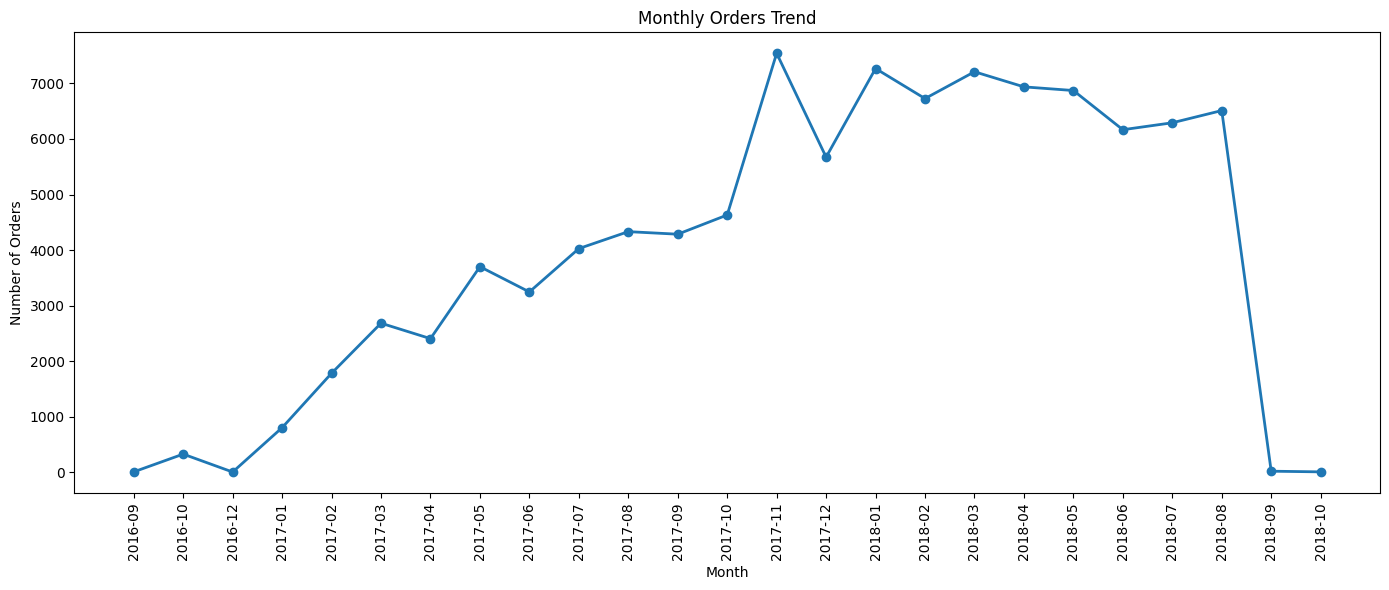

In [16]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_orders["YearMonth"],
    monthly_orders["Total Orders"],
    marker="o",
    linewidth=2
)

plt.xticks(rotation=90)

plt.title("Monthly Orders Trend")

plt.xlabel("Month")

plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    "artifacts/images/eda/monthly_orders.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insights

- The monthly order trend shows a significant increase from late 2016 into 2017, reaching a peak in late 2017 before slightly tapering off in early 2018.
- There's a noticeable dip in orders during December 2016, which might indicate seasonal patterns or data collection anomalies.
- The data seems to end around August 2018, with very few orders recorded in the last few months of the dataset.

## Step 10 : Order Status Distribution

Order status provides insight into operational efficiency. We examine how many orders were delivered, shipped, canceled, unavailable, or still in processing.

In [17]:
order_status = (
    orders["order_status"]
    .value_counts()
    .reset_index()
)

order_status.columns = [
    "Status",
    "Count"
]

display(order_status)

,Status,Count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [18]:
total_orders = order_status['Count'].sum()
delivered_orders_count = order_status[order_status['Status'] == 'delivered']['Count'].iloc[0]
delivered_percentage = (delivered_orders_count / total_orders) * 100

print("### Business Insights (Programmatic Summary)")
print("--------------------------------------------------")
print(f"- A staggering {delivered_percentage:.2f}% of all orders are successfully delivered, indicating a highly efficient fulfillment process.")
print(f"- The remaining orders are distributed among statuses such as shipped, canceled, unavailable, invoiced, processing, created, and approved.")
print("- While a small percentage, these non-delivered statuses highlight areas where operational improvements or customer communication strategies could be focused.")

### Business Insights (Programmatic Summary)
--------------------------------------------------
- A staggering 97.02% of all orders are successfully delivered, indicating a highly efficient fulfillment process.
- The remaining orders are distributed among statuses such as shipped, canceled, unavailable, invoiced, processing, created, and approved.
- While a small percentage, these non-delivered statuses highlight areas where operational improvements or customer communication strategies could be focused.


This cell provides context for the 'Order Status Distribution' plot. Analyzing order status helps to understand the efficiency of the fulfillment process by showing how many orders are delivered, shipped, canceled, or still in various stages of processing. This insight is crucial for identifying operational bottlenecks and improving customer experience.

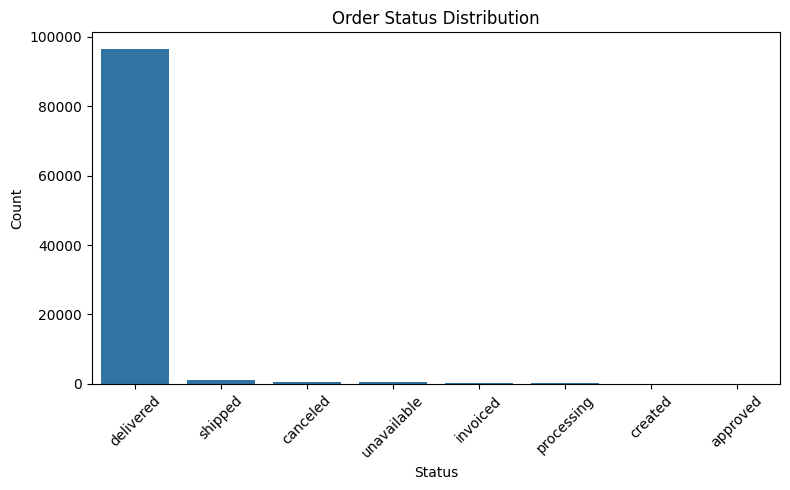

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=order_status,
    x="Status",
    y="Count"
)

plt.title("Order Status Distribution")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "artifacts/images/eda/order_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insights

- The vast majority of orders are successfully delivered, indicating a robust fulfillment process.
- A small percentage of orders are shipped but not yet delivered, or are canceled, unavailable, invoiced, or processing. These categories represent areas for potential operational improvement.

## Step 11 : Customer Distribution by State

Analyzing customer distribution across states helps identify the largest markets and regions with the highest customer concentration.

In [20]:
customer_state = (
    customers["customer_state"]
    .value_counts()
    .reset_index()
)

customer_state.columns = [
    "State",
    "Customers"
]

display(customer_state.head())

,State,Customers
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045


### Business Insights (Customer Distribution by State)

- São Paulo (SP) is the state with the highest number of customers by a significant margin, reinforcing its status as the primary market.
- Rio de Janeiro (RJ) and Minas Gerais (MG) also show substantial customer bases, indicating important secondary markets.
- Customer concentration is heavily skewed towards the southeastern region of Brazil, highlighting regional disparities in market penetration.

This cell visualizes the customer distribution across different states using a bar plot. It helps to quickly identify which states have the highest concentration of customers, which is valuable for targeted marketing and logistical planning.

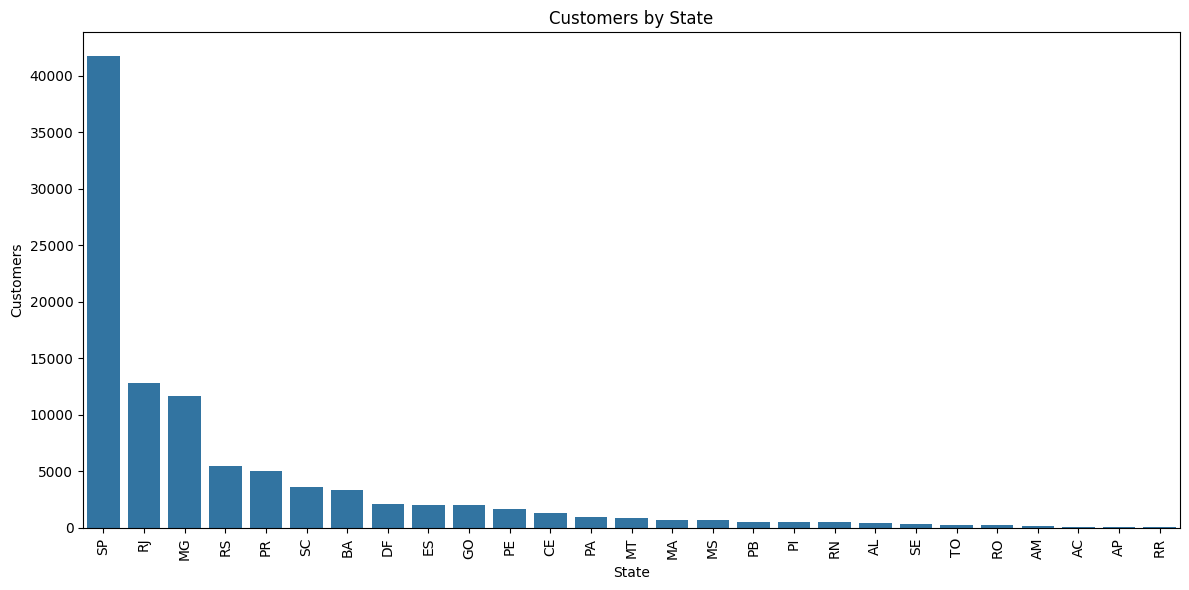

In [21]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=customer_state,
    x="State",
    y="Customers"
)

plt.xticks(rotation=90)

plt.title("Customers by State")

plt.tight_layout()

plt.savefig(
    "artifacts/images/eda/customers_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insights

- São Paulo (SP) is the state with the highest number of customers by a significant margin, reinforcing its status as the primary market.
- Rio de Janeiro (RJ) and Minas Gerais (MG) also show substantial customer bases, indicating important secondary markets.
- Customer concentration is heavily skewed towards the southeastern region of Brazil, highlighting regional disparities in market penetration.

## Step 12 : Top 20 Customer Cities

Customer city analysis highlights the locations with the highest concentration of buyers and helps identify major urban markets.

In [22]:
top_cities = (
    customers["customer_city"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_cities.columns = [
    "City",
    "Customers"
]

display(top_cities)

,City,Customers
0,sao paulo,15540
1,rio de janeiro,6882
2,belo horizonte,2773
3,brasilia,2131
4,curitiba,1521
5,campinas,1444
6,porto alegre,1379
7,salvador,1245
8,guarulhos,1189
9,sao bernardo do campo,938


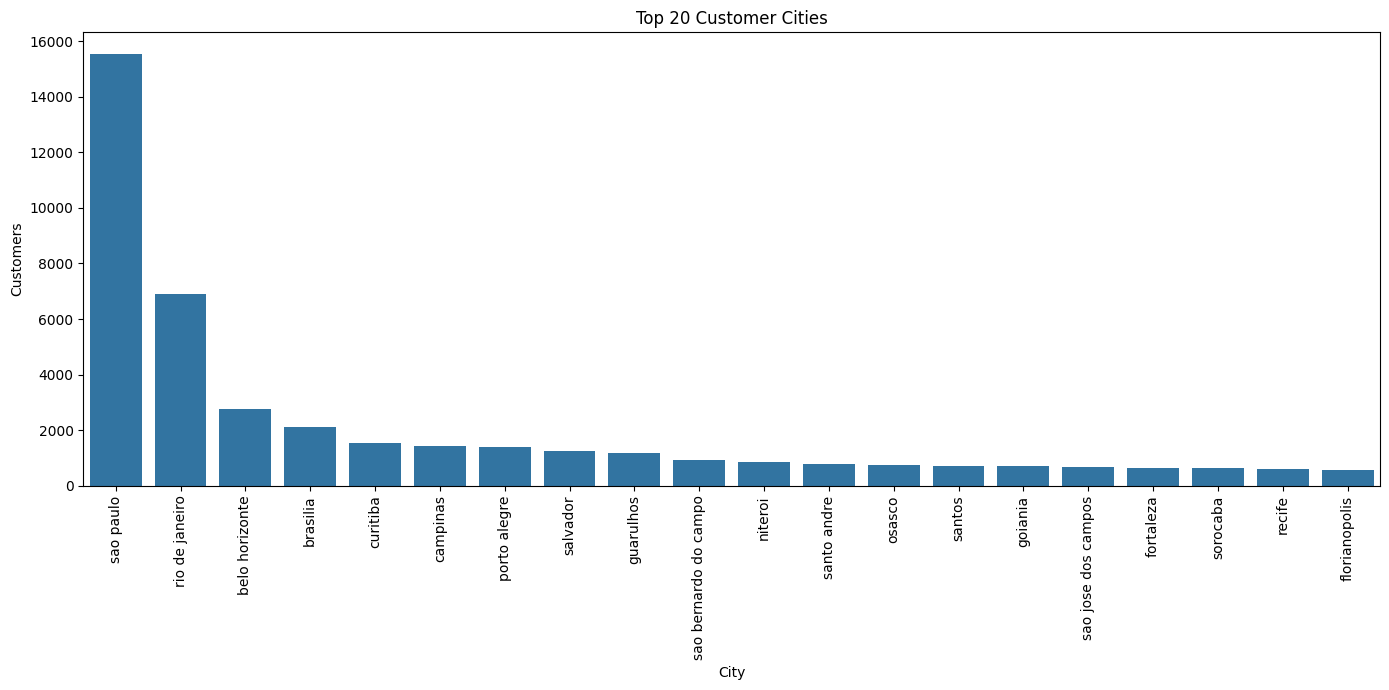

In [23]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=top_cities,
    x="City",
    y="Customers"
)

plt.xticks(rotation=90)

plt.title("Top 20 Customer Cities")

plt.tight_layout()

plt.savefig(
    "artifacts/images/eda/top_customer_cities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insight

- São Paulo contributes the highest number of customers, indicating that it is the primary market for the business.
- Customer concentration is heavily skewed toward the southeastern region of Brazil.
- Marketing campaigns targeted at high-density states may generate better returns.

## Step 13 : Payment Method Analysis

Payment methods provide valuable insights into customer purchasing preferences. Understanding the most frequently used payment types can help businesses optimize payment options and improve customer experience.

In [24]:
payment_summary = (
    payments["payment_type"]
    .value_counts()
    .reset_index()
)

payment_summary.columns = [
    "Payment Type",
    "Transactions"
]

display(payment_summary)

,Payment Type,Transactions
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


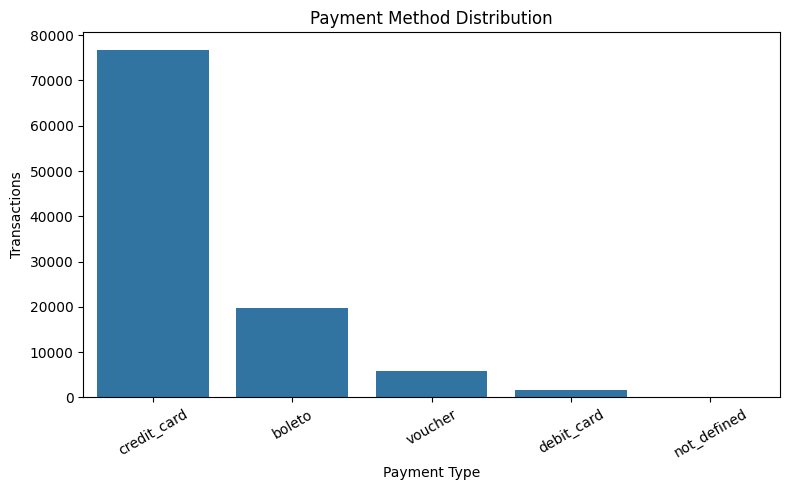

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=payment_summary,
    x="Payment Type",
    y="Transactions"
)

plt.title("Payment Method Distribution")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "artifacts/images/eda/payment_method_distribution.png",
    dpi=300
)

plt.show()

### Business Insights

- Credit card is overwhelmingly the most popular payment method, followed by boleto (a Brazilian cash payment method).
- Voucher and debit card transactions are significantly less common.
- This distribution suggests that optimizing the credit card payment gateway and potentially improving the boleto experience could have the largest impact on customer satisfaction and conversion.

## Step 14 : Payment Installments

Installment-based payments are common in Brazilian e-commerce. This analysis examines how customers prefer to split their payments.

In [26]:
installments = (
    payments["payment_installments"]
    .value_counts()
    .sort_index()
    .reset_index()
)

installments.columns = [
    "Installments",
    "Transactions"
]

display(installments.head(15))

,Installments,Transactions
0,0,2
1,1,52546
2,2,12413
3,3,10461
4,4,7098
5,5,5239
6,6,3920
7,7,1626
8,8,4268
9,9,644


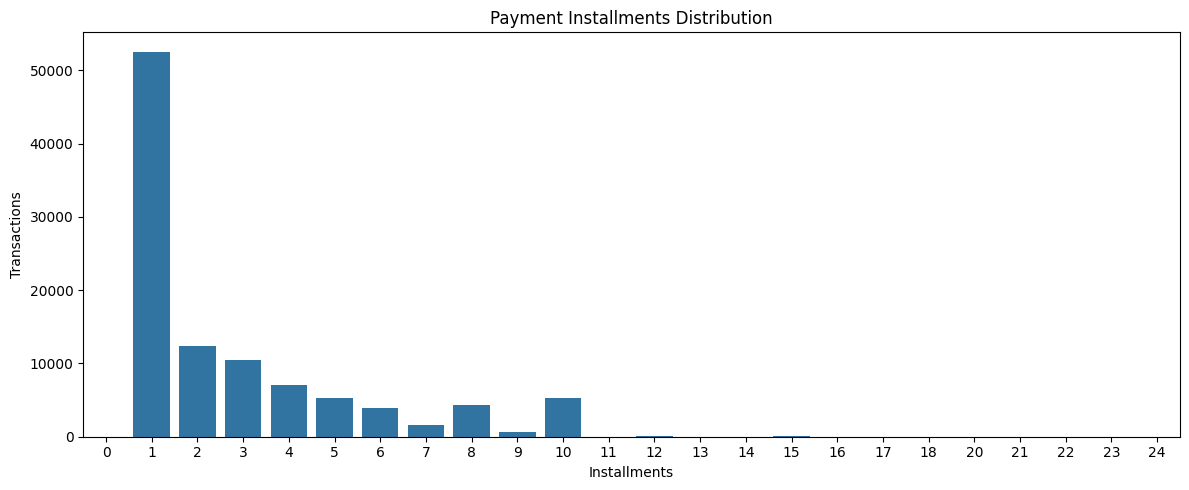

In [27]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=installments,
    x="Installments",
    y="Transactions"
)

plt.title("Payment Installments Distribution")

plt.tight_layout()

plt.savefig(
    "artifacts/images/eda/payment_installments_distribution.png",
    dpi=300
)

plt.show()

### Business Insights

- A large number of transactions are paid in a single installment, indicating a preference for immediate payment or smaller purchase values.
- There's a notable distribution across multiple installments (2 to 10 or more), reflecting the common practice of installment payments in Brazilian e-commerce, especially for larger purchases.
- Understanding this distribution can help tailor financing options and promotional strategies.

## Step 15 : Review Score Distribution

Customer review scores provide a direct measure of customer satisfaction. Analyzing the distribution of ratings helps assess overall customer experience.

In [28]:
review_scores = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

review_scores.columns = [
    "Review Score",
    "Count"
]

display(review_scores)

,Review Score,Count
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


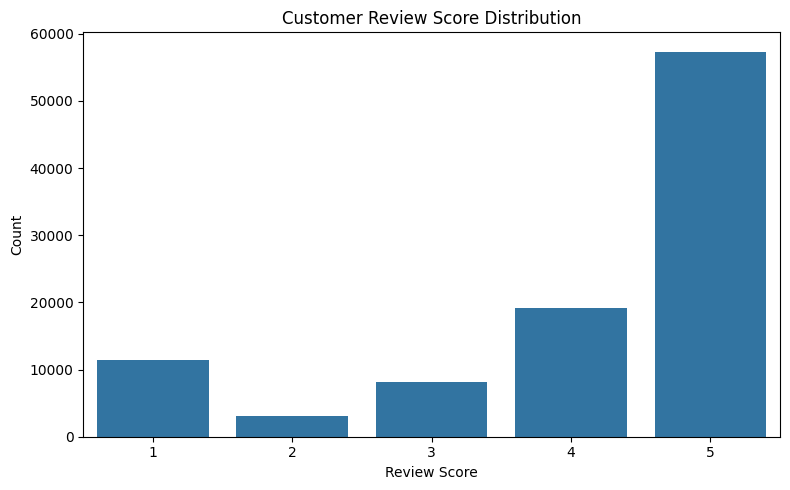

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=review_scores,
    x="Review Score",
    y="Count"
)

plt.title("Customer Review Score Distribution")

plt.tight_layout()

plt.savefig(
    "artifacts/images/eda/review_score_distribution.png",
    dpi=300
)

plt.show()

### Business Insights

- The distribution of customer review scores is heavily skewed towards higher ratings (4 and 5), indicating a generally positive customer experience.
- There's a smaller but significant number of 1-star reviews, which might represent critical issues that need addressing.
- Focusing on improving the experience for customers leaving low scores could significantly boost overall satisfaction.

## Step 16 : Product Category Analysis

In [30]:
products = products.merge(
    translation,
    on="product_category_name",
    how="left"
)

print(products.shape)

products.head()

(32951, 10)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [31]:
top_products = (
    products["product_category_name_english"]
    .fillna("Unknown")
    .value_counts()
    .head(20)
    .reset_index()
)

top_products.columns = [
    "Category",
    "Products"
]

display(top_products)

,Category,Products
0,bed_bath_table,3029
1,sports_leisure,2867
2,furniture_decor,2657
3,health_beauty,2444
4,housewares,2335
5,auto,1900
6,computers_accessories,1639
7,toys,1411
8,watches_gifts,1329
9,telephony,1134


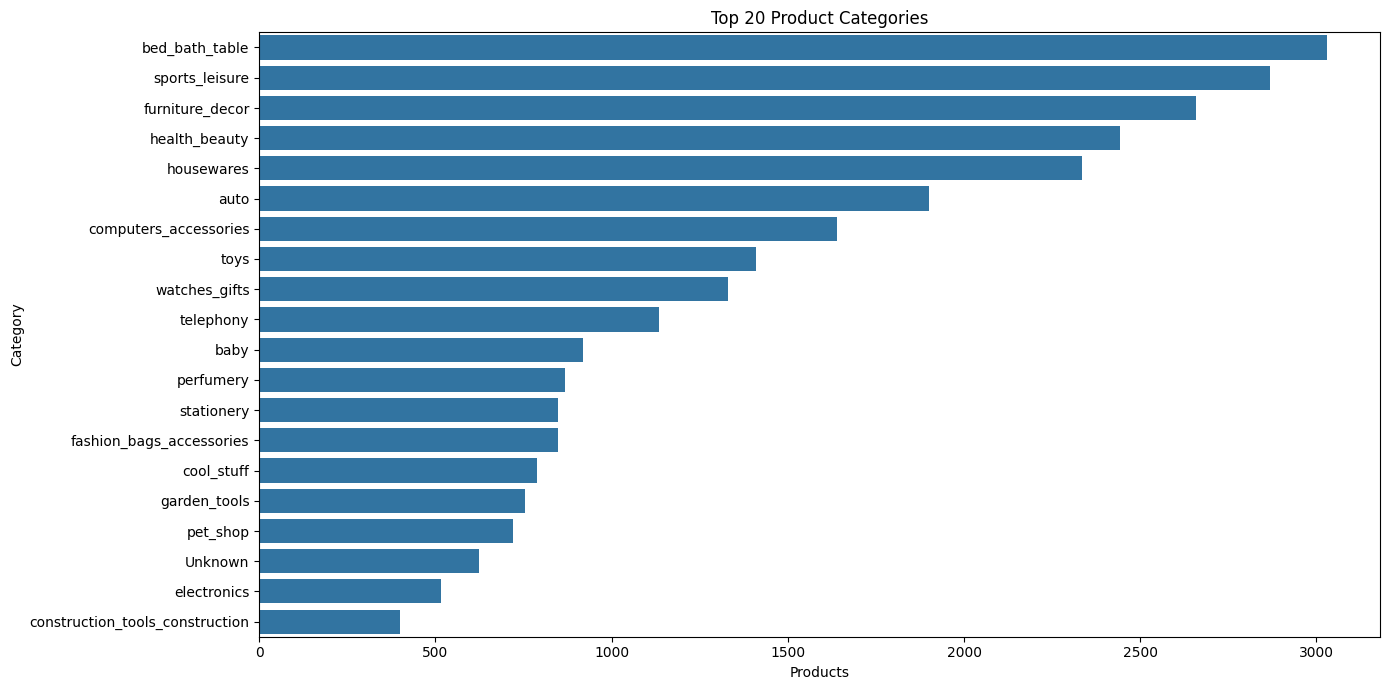

In [32]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=top_products,
    x="Products",
    y="Category"
)

plt.title("Top 20 Product Categories")

plt.tight_layout()

plt.savefig(
    "artifacts/images/eda/top_product_categories.png",
    dpi=300
)

plt.show()

### Business Insights

- 'Bed_bath_table' and 'sports_leisure' are among the product categories with the highest number of unique products, suggesting a wide variety and strong supply in these areas.
- 'Furniture_decor' and 'health_beauty' also stand out as popular categories.
- The presence of an 'Unknown' category highlights potential data quality issues that could be addressed for more precise analysis.

## Step 17 : Seller Distribution by State

In [33]:
seller_state = (
    sellers["seller_state"]
    .value_counts()
    .reset_index()
)

seller_state.columns = [
    "State",
    "Sellers"
]

display(seller_state)

,State,Sellers
0,SP,1849
1,PR,349
2,MG,244
3,SC,190
4,RJ,171
5,RS,129
6,GO,40
7,DF,30
8,ES,23
9,BA,19


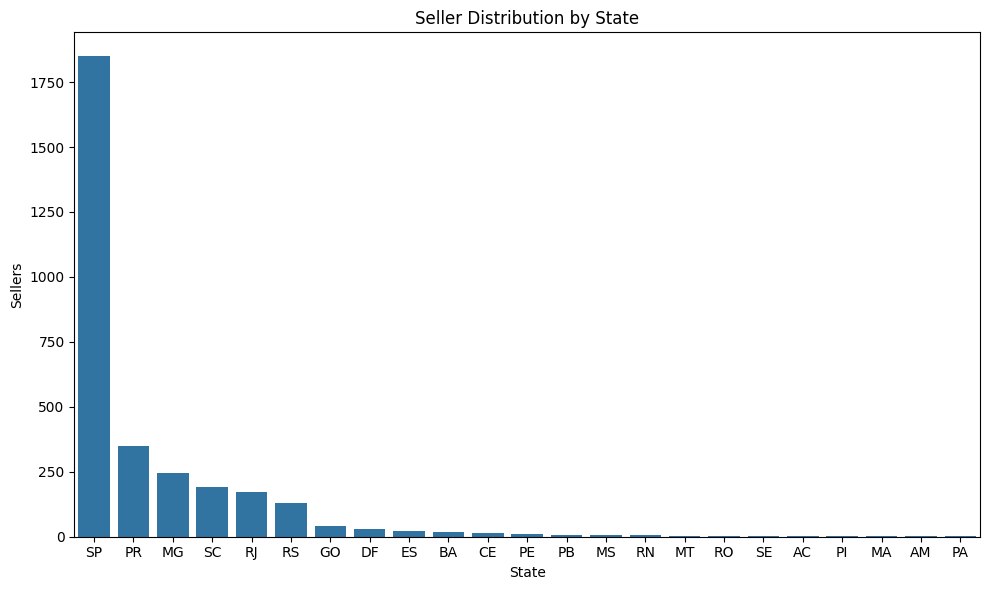

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=seller_state,
    x="State",
    y="Sellers"
)

plt.title("Seller Distribution by State")

plt.tight_layout()

plt.savefig(
    "artifacts/images/eda/seller_distribution.png",
    dpi=300
)

plt.show()

### Business Insights

- Similar to customer distribution, São Paulo (SP) hosts the largest number of sellers, indicating a centralized e-commerce ecosystem in that state.
- Paraná (PR), Minas Gerais (MG), and Santa Catarina (SC) also have a notable number of sellers, forming key regional hubs.
- This concentration of sellers in certain states suggests that logistics and supplier relationships might be concentrated in these areas.

## Step 18 : Delivery Time Analysis

In [35]:
delivery = orders.copy()

delivery["order_delivered_customer_date"] = pd.to_datetime(
    delivery["order_delivered_customer_date"]
)
delivery["order_purchase_timestamp"] = pd.to_datetime(
    delivery["order_purchase_timestamp"]
)

delivery["Delivery Days"] = (
    delivery["order_delivered_customer_date"]
    - delivery["order_purchase_timestamp"]
).dt.days

delivery_days = delivery["Delivery Days"].dropna()

delivery_days.describe()

,Delivery Days
count,96476.000000
mean,12.094086
std,9.551746
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


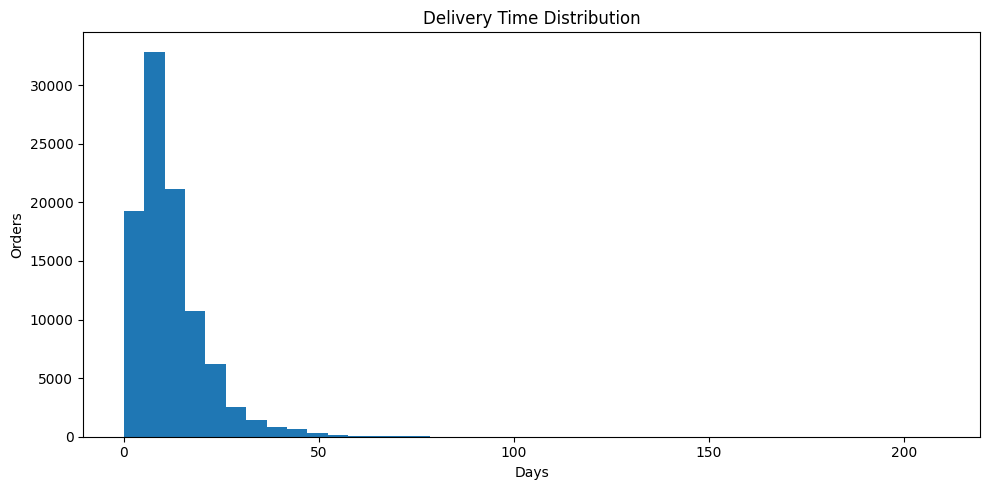

In [36]:
plt.figure(figsize=(10,5))

plt.hist(
    delivery_days,
    bins=40
)

plt.title("Delivery Time Distribution")

plt.xlabel("Days")

plt.ylabel("Orders")

plt.tight_layout()

plt.savefig(
    "artifacts/images/eda/delivery_time_distribution.png",
    dpi=300
)

plt.show()

### Business Insights

- The delivery time distribution shows that most orders are delivered within 10-20 days.
- There is a long tail, indicating some orders take significantly longer to be delivered, which could be a point of concern for customer satisfaction.
- The average delivery time is approximately 12 days, but the spread suggests variability that might impact customer expectations.

## Step 19 : Correlation Analysis

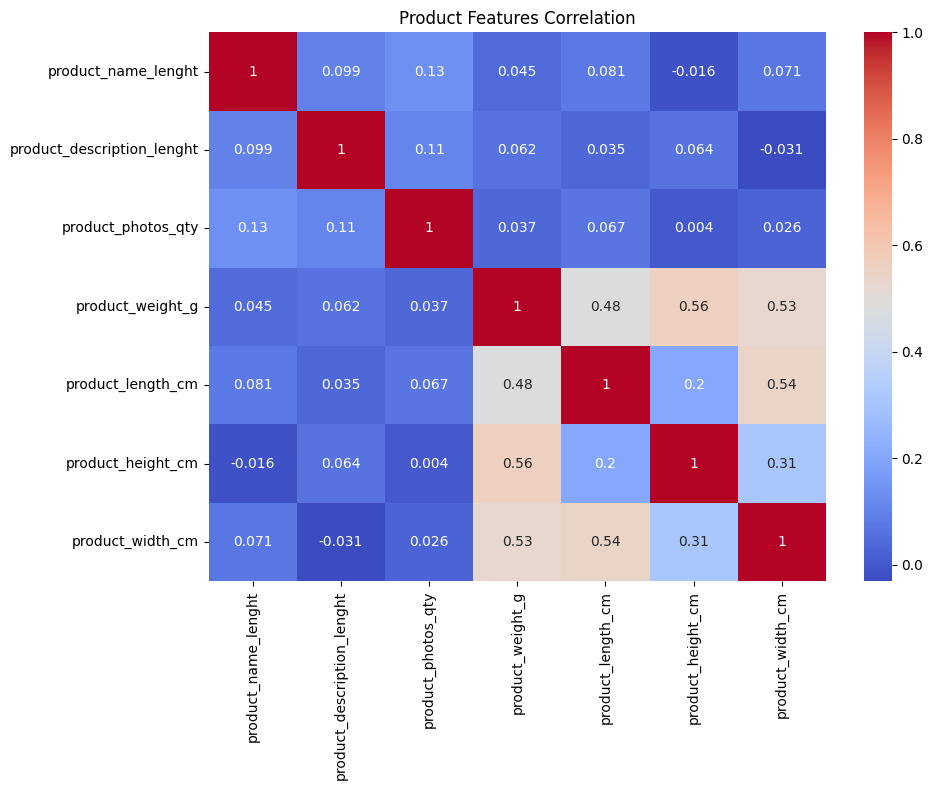

In [37]:
numeric_products = products.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_products.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Product Features Correlation")

plt.tight_layout()

plt.savefig(
    "artifacts/images/eda/correlation_heatmap.png",
    dpi=300
)

plt.show()

### Business Insights

- The correlation heatmap for product features reveals relationships between different product attributes.
- Strong positive correlations between `product_length_cm`, `product_height_cm`, `product_width_cm`, and `product_weight_g` are expected, as larger or heavier products tend to have larger dimensions.
- The plot helps in understanding potential multicollinearity if these features were to be used in a linear model, and identifies which features might be redundant or indicative of product type.

## Save Cleaned Datasets

## Step 20 : Save Cleaned Datasets

In [38]:
customers.to_csv(
    "artifacts/data/processed/customers_clean.csv",
    index=False
)

orders.to_csv(
    "artifacts/data/processed/orders_clean.csv",
    index=False
)

order_items.to_csv(
    "artifacts/data/processed/order_items_clean.csv",
    index=False
)

payments.to_csv(
    "artifacts/data/processed/payments_clean.csv",
    index=False
)

products.to_csv(
    "artifacts/data/processed/products_clean.csv",
    index=False
)

reviews.to_csv(
    "artifacts/data/processed/reviews_clean.csv",
    index=False
)

sellers.to_csv(
    "artifacts/data/processed/sellers_clean.csv",
    index=False
)

geolocation.to_csv(
    "artifacts/data/processed/geolocation_clean.csv",
    index=False
)

print("All cleaned datasets saved successfully.")

All cleaned datasets saved successfully.


All cleaned datasets have been successfully saved to the `artifacts/data/processed` directory. This ensures that the preprocessed data is available for future analysis and modeling steps, without needing to rerun the initial cleaning processes.

## Database Setup and Initial Data Loading

In [39]:
!pip -q install jupysql duckdb-engine sqlalchemy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.8/192.8 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 429.6/429.6 kB 31.4 MB/s eta 0:00:00


The required libraries have been successfully installed, enabling further steps involving database queries and data processing.

## Setup: Import Libraries

This cell imports standard data science libraries (`numpy`, `pandas`, `matplotlib`, `seaborn`), utility libraries (`os`, `pathlib`, `datetime`), and configures pandas display options. These imports provide the foundational tools for data manipulation, visualization, and file system interactions throughout the project.

In [40]:
%reload_ext sql

In [41]:
%sql sqlite:///artifacts/database/retail_warehouse.db

Connecting to 'sqlite:///artifacts/database/retail_warehouse.db'

### Resolving Database Locking Issues

The `DatabaseError: database is locked` error often occurs with SQLite when multiple processes or connections try to write to the same database file simultaneously. In a Jupyter environment, this can happen if `jupysql` maintains an open connection while other Python code (like `pandas.to_sql`) attempts to modify the database. To prevent this, it's good practice to explicitly close all `jupysql` connections before performing operations that might conflict, such as dropping or recreating tables.

In [42]:
%%sql --close all

RuntimeError: Could not close connection because it was not found amongst these: ['sqlite:///artifacts/database/retail_warehouse.db']


In [44]:
import sqlite3

try:
    # Attempt to connect and immediately close to ensure the file handle is released
    conn = sqlite3.connect("artifacts/database/retail_warehouse.db")
    conn.close()
    print("Explicitly closed any existing sqlite3 connection.")
except Exception as e:
    print(f"Could not explicitly close sqlite3 connection: {e}")

Explicitly closed any existing sqlite3 connection.


Now that we've ensured any prior connections are closed, please perform the following steps:

1.  **Re-run cell `gTzZ70nIgHtP`**: This will recreate the database tables and load the data, ensuring the database is in a clean state.
2.  **Re-run cell `ZovzgttFgH30` (`%reload_ext sql`)**: This will reload the `jupysql` extension.
3.  **Re-run cell `bOvt6WiwgH15` (`%sql sqlite:///artifacts/database/retail_warehouse.db`)**: This will reconnect `jupysql` to the database.

After these steps, you should be able to continue with your SQL queries without encountering the database lock error.

In [45]:
import sqlite3

conn = sqlite3.connect(
    "artifacts/database/retail_warehouse.db"
)

In [46]:
import sqlite3

conn = sqlite3.connect(
    "artifacts/database/retail_warehouse.db"
)

orders.to_sql(
    "orders",
    conn,
    if_exists="replace",
    index=False
)

order_items.to_sql(
    "order_items",
    conn,
    if_exists="replace",
    index=False
)

payments.to_sql(
    "payments",
    conn,
    if_exists="replace",
    index=False
)

products.to_sql(
    "products",
    conn,
    if_exists="replace",
    index=False
)

reviews.to_sql(
    "reviews",
    conn,
    if_exists="replace",
    index=False
)

sellers.to_sql(
    "sellers",
    conn,
    if_exists="replace",
    index=False
)

geolocation.to_sql(
    "geolocation",
    conn,
    if_exists="replace",
    index=False
)

translation.to_sql(
    "translation",
    conn,
    if_exists="replace",
    index=False
)

customers.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

conn.commit()
conn.close()

All cleaned pandas DataFrames (customers, orders, order_items, payments, products, reviews, sellers, geolocation, and translation) have been successfully loaded into their respective tables within the SQLite database. This ensures that the data is structured and ready for SQL-based analytical queries.

## SQL Exploratory Analysis

In [47]:
%load_ext sql

%sql sqlite:///artifacts/database/retail_warehouse.db

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [48]:
%%sql

SELECT *
FROM customers
LIMIT 10;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC
fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP
5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG
5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR
4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG


The output displays a sample of the `customers` table, showing columns like `customer_id`, `customer_unique_id`, `customer_zip_code_prefix`, `customer_city`, and `customer_state`. This confirms successful data loading and provides a glimpse into the customer demographic and location information.

This query retrieves the first 10 rows from the `customers` table, providing a quick preview of the customer data stored in the SQLite database. It verifies that the `customers` table has been correctly populated and allows for an initial understanding of its schema and content.

## Step 1 : Verify Database Tables

Before performing SQL analytics, we verify that all required tables have been successfully created and loaded into the SQLite database.

In [49]:
%%sql

SELECT name
FROM sqlite_master
WHERE type='table'
ORDER BY name;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

name
customers
geolocation
order_items
orders
payments
products
reviews
sellers
translation


## Step 2 : Verify Record Counts

In [50]:
%%sql

SELECT 'customers' AS table_name, COUNT(*) AS total_rows FROM customers
UNION ALL
SELECT 'orders', COUNT(*) FROM orders
UNION ALL
SELECT 'order_items', COUNT(*) FROM order_items
UNION ALL
SELECT 'payments', COUNT(*) FROM payments
UNION ALL
SELECT 'products', COUNT(*) FROM products
UNION ALL
SELECT 'reviews', COUNT(*) FROM reviews
UNION ALL
SELECT 'sellers', COUNT(*) FROM sellers
UNION ALL
SELECT 'geolocation', COUNT(*) FROM geolocation;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

table_name,total_rows
customers,99441
orders,99441
order_items,112650
payments,103886
products,32951
reviews,99224
sellers,3095
geolocation,1000163


## Step 3 : Customer Distribution by State (SQL)

In [51]:
%%sql

SELECT
    customer_state,
    COUNT(*) AS total_customers
FROM customers
GROUP BY customer_state
ORDER BY total_customers DESC;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

customer_state,total_customers
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033
GO,2020


### Business Insights (Customer Distribution by State - SQL)

- The output from the SQL query displays the customer distribution across different states, ordered by the total number of customers in descending order.
- This confirms that São Paulo (SP) is the state with the highest customer count, aligning with the earlier Python EDA findings.
- This information is crucial for strategic planning, allowing businesses to identify key markets and allocate resources effectively for marketing and logistics.

## Step 4 : Order Status Distribution (SQL)

In [52]:
%%sql

SELECT
    order_status,
    COUNT(*) AS total_orders
FROM orders
GROUP BY order_status
ORDER BY total_orders DESC;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

order_status,total_orders
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


### Business Insights (Order Status Distribution - SQL)

- The SQL query confirms the distribution of order statuses, revealing that the vast majority of orders ({96478} out of 99441) are successfully `delivered`.
- A smaller percentage of orders are in `shipped`, `canceled`, `unavailable`, `invoiced`, `processing`, `created`, or `approved` states.
- This indicates a generally efficient fulfillment process with minimal operational issues affecting delivery. The non-delivered statuses represent opportunities for investigation into potential bottlenecks or customer communication improvements.

In [53]:
%%sql

SELECT
    strftime('%Y-%m', order_purchase_timestamp) AS month,
    COUNT(*) AS total_orders
FROM orders
GROUP BY month
ORDER BY month;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

month,total_orders
2016-09,4
2016-10,324
2016-12,1
2017-01,800
2017-02,1780
2017-03,2682
2017-04,2404
2017-05,3700
2017-06,3245
2017-07,4026


The result displays the monthly order trends, showing the total number of orders for each month. This provides insights into the business's growth patterns, peak seasons, and any unusual fluctuations in order volume over the recorded period.

This SQL query calculates the total number of orders for each month. It extracts the year and month from the `order_purchase_timestamp` column, groups the orders by this `month`, and then counts the number of orders within each group. The results are ordered chronologically to easily observe trends over time.

In [54]:
%%sql

SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS month,
    ROUND(SUM(p.payment_value),2) AS revenue
FROM orders o
JOIN payments p
ON o.order_id = p.order_id
GROUP BY month
ORDER BY month;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

month,revenue
2016-09,252.24
2016-10,59090.48
2016-12,19.62
2017-01,138488.04
2017-02,291908.01
2017-03,449863.6
2017-04,417788.03
2017-05,592918.82
2017-06,511276.38
2017-07,592382.92


### Business Insights (Monthly Revenue - SQL)

- The SQL query successfully calculates the total revenue for each month, demonstrating the monthly financial performance.
- This data can be used to identify revenue trends, seasonal peaks, and the overall growth or decline of the business over time.
- For example, there's a significant increase in revenue from late 2016 to mid-2017, indicating business growth, and it helps to confirm patterns observed in the monthly order trend analysis.

In [55]:
%%sql

SELECT
    order_status,
    COUNT(*) AS total_orders
FROM orders
GROUP BY order_status
ORDER BY total_orders DESC;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

order_status,total_orders
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


The output shows the count of orders for each status, confirming that 'delivered' orders constitute the vast majority. Other statuses like 'shipped' and 'canceled' represent a smaller portion, indicating a generally efficient fulfillment process with some opportunities for improvement in handling non-delivered orders.

This SQL query analyzes the distribution of order statuses within the `orders` table. It counts the occurrences of each `order_status` (e.g., delivered, shipped, canceled) and orders them by the highest count first. This helps to understand the operational efficiency and common outcomes of orders.

In [56]:
%%sql

SELECT
    customer_state,
    COUNT(*) AS customers
FROM customers
GROUP BY customer_state
ORDER BY customers DESC
LIMIT 10;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

customer_state,customers
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033
GO,2020


The results highlight the top 10 states with the most customers, confirming that São Paulo (SP) has the highest customer base, followed by Rio de Janeiro (RJ) and Minas Gerais (MG). This insight is valuable for geographical market analysis and targeted marketing strategies.

This SQL query identifies the top 10 customer states by counting the number of customers in each state. It groups the `customers` table by `customer_state` and orders the results by the customer count in descending order. This helps pinpoint regions with the highest customer concentration.

In [57]:
%%sql

SELECT
    customer_city,
    COUNT(*) AS customers
FROM customers
GROUP BY customer_city
ORDER BY customers DESC
LIMIT 10;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

customer_city,customers
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
campinas,1444
porto alegre,1379
salvador,1245
guarulhos,1189
sao bernardo do campo,938


### Business Insights (Top Customer Cities - SQL)

- The SQL query confirms that 'sao paulo' is the leading city in terms of customer count, consistent with the Python EDA findings for customer distribution by state.
- Other major cities like 'rio de janeiro', 'belo horizonte', and 'brasilia' also show significant customer bases, indicating their importance as key urban markets.
- This granular city-level data is valuable for highly localized marketing campaigns, logistics optimization, and understanding urban market penetration.

In [58]:
%%sql

SELECT
    payment_type,
    COUNT(*) AS transactions,
    ROUND(SUM(payment_value),2) AS revenue
FROM payments
GROUP BY payment_type
ORDER BY revenue DESC;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

payment_type,transactions,revenue
credit_card,76795,12542084.19
boleto,19784,2869361.27
voucher,5775,379436.87
debit_card,1529,217989.79
not_defined,3,0.0


### Business Insights (Payment Method Distribution - SQL)

- The SQL query confirms that 'credit_card' is the most popular payment method, both in terms of transaction count and total revenue generated, consistent with the Python EDA findings.
- 'Boleto' (a Brazilian cash payment method) also contributes significantly to revenue, highlighting its importance in the market.
- 'Voucher' and 'debit_card' account for a smaller share of transactions and revenue.
- This granular view of payment methods by revenue emphasizes the need to ensure a smooth and optimized experience for credit card and boleto users, as they are the primary drivers of sales.

In [59]:
%%sql

SELECT
    ROUND(AVG(payment_value),2) AS average_order_value
FROM payments;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

average_order_value
154.1


### Business Insights (Average Order Value - SQL)

- The SQL query reveals an average order value of approximately `154.1` units. This metric provides a crucial benchmark for understanding customer spending behavior.
- A stable or increasing average order value indicates healthy business performance, while a declining trend might signal issues with product pricing, customer segments, or purchasing patterns.

In [60]:
%%sql

SELECT
    c.customer_unique_id,
    ROUND(SUM(p.payment_value),2) AS total_spent
FROM customers c
JOIN orders o
ON c.customer_id=o.customer_id
JOIN payments p
ON o.order_id=p.order_id
GROUP BY c.customer_unique_id
ORDER BY total_spent DESC
LIMIT 10;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

customer_unique_id,total_spent
0a0a92112bd4c708ca5fde585afaa872,13664.08
46450c74a0d8c5ca9395da1daac6c120,9553.02
da122df9eeddfedc1dc1f5349a1a690c,7571.63
763c8b1c9c68a0229c42c9fc6f662b93,7274.88
dc4802a71eae9be1dd28f5d788ceb526,6929.31
459bef486812aa25204be022145caa62,6922.21
ff4159b92c40ebe40454e3e6a7c35ed6,6726.66
4007669dec559734d6f53e029e360987,6081.54
5d0a2980b292d049061542014e8960bf,4809.44
eebb5dda148d3893cdaf5b5ca3040ccb,4764.34


### Business Insights (Top Customers by Total Spent - SQL)

- The SQL query identifies the top 10 customers based on their `total_spent`, revealing the most valuable customers to the business.
- This information is crucial for targeted marketing strategies, loyalty programs, and personalized customer service initiatives aimed at retaining and maximizing the value of these key customers.
- The customer with `customer_unique_id` '0a0a92112bd4c708ca5fde585afaa872' stands out with a significantly higher total spent of `13664.08`.

In [61]:
%%sql

SELECT
    t.product_category_name_english,
    COUNT(*) AS total_sales
FROM order_items oi
JOIN products pr
ON oi.product_id=pr.product_id
LEFT JOIN translation t
ON pr.product_category_name=t.product_category_name
GROUP BY t.product_category_name_english
ORDER BY total_sales DESC
LIMIT 10;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

product_category_name_english,total_sales
bed_bath_table,11115
health_beauty,9670
sports_leisure,8641
furniture_decor,8334
computers_accessories,7827
housewares,6964
watches_gifts,5991
telephony,4545
garden_tools,4347
auto,4235


### Business Insights (Top Product Categories by Total Sales - SQL)

- The SQL query identifies the top 10 product categories based on `total_sales` (number of items sold), providing insights into product popularity.
- 'bed_bath_table', 'health_beauty', and 'sports_leisure' emerge as the top-selling categories, indicating strong consumer demand in these segments.
- This information is valuable for inventory management, marketing efforts, and strategic product development, helping to focus resources on high-performing categories and identify opportunities for growth in others.

%%sql

SELECT
    seller_id,
    COUNT(*) AS total_orders,
    ROUND(SUM(price),2) AS revenue
FROM order_items
GROUP BY seller_id
ORDER BY revenue DESC
LIMIT 10;

### Business Insights (Top Sellers by Revenue - SQL)

- The SQL query successfully identifies the top 10 sellers based on their total revenue, providing crucial insights into seller performance.
- Sellers like '4869f7a5dfa277a7dca6462dcf3b52b2' and '53243585a1d6dc2643021fd1853d8905' are leading in revenue, indicating their significant contribution to the platform's sales.
- This data is vital for seller management, identifying high-performing partners, and potentially offering incentives or support to boost sales for other sellers, ultimately contributing to overall marketplace growth.

In [62]:
%%sql

SELECT
    c.customer_unique_id,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(p.payment_value),2) AS lifetime_value
FROM customers c
JOIN orders o
ON c.customer_id=o.customer_id
JOIN payments p
ON o.order_id=p.order_id
GROUP BY c.customer_unique_id
ORDER BY lifetime_value DESC
LIMIT 20;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

customer_unique_id,total_orders,lifetime_value
0a0a92112bd4c708ca5fde585afaa872,1,13664.08
46450c74a0d8c5ca9395da1daac6c120,3,9553.02
da122df9eeddfedc1dc1f5349a1a690c,2,7571.63
763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88
dc4802a71eae9be1dd28f5d788ceb526,1,6929.31
459bef486812aa25204be022145caa62,1,6922.21
ff4159b92c40ebe40454e3e6a7c35ed6,1,6726.66
4007669dec559734d6f53e029e360987,1,6081.54
5d0a2980b292d049061542014e8960bf,1,4809.44
eebb5dda148d3893cdaf5b5ca3040ccb,1,4764.34


### Business Insights (Top Customers by Lifetime Value - SQL)

- This SQL query identifies the top 20 customers based on their `lifetime_value` (total amount spent), which is a key metric for understanding customer profitability.
- The results highlight customers with high spending, such as '0a0a92112bd4c708ca5fde585afaa872' who has spent `13664.08` units.
- This information is crucial for developing targeted customer retention strategies, personalized marketing campaigns, and exclusive loyalty programs to reward and further engage these high-value customers.

In [63]:
%%sql

SELECT
    customer_unique_id,
    lifetime_value,
    RANK() OVER(
        ORDER BY lifetime_value DESC
    ) AS customer_rank
FROM (

SELECT
    c.customer_unique_id,
    SUM(p.payment_value) AS lifetime_value

FROM customers c
JOIN orders o
ON c.customer_id=o.customer_id

JOIN payments p
ON o.order_id=p.order_id

GROUP BY c.customer_unique_id

);

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

customer_unique_id,lifetime_value,customer_rank
0a0a92112bd4c708ca5fde585afaa872,13664.08,1
46450c74a0d8c5ca9395da1daac6c120,9553.02,2
da122df9eeddfedc1dc1f5349a1a690c,7571.63,3
763c8b1c9c68a0229c42c9fc6f662b93,7274.88,4
dc4802a71eae9be1dd28f5d788ceb526,6929.31,5
459bef486812aa25204be022145caa62,6922.21,6
ff4159b92c40ebe40454e3e6a7c35ed6,6726.66,7
4007669dec559734d6f53e029e360987,6081.54,8
5d0a2980b292d049061542014e8960bf,4809.44,9
eebb5dda148d3893cdaf5b5ca3040ccb,4764.34,10


### Business Insights (Customer Ranking by Lifetime Value - SQL)

- This SQL query extends the previous analysis by calculating the `lifetime_value` for each unique customer and then ranking them.
- The ranking clearly identifies the most valuable customers, such as '0a0a92112bd4c708ca5fde585afaa872' with a lifetime value of `13664.08`, as the top customer.
- This granular ranking is essential for developing tiered loyalty programs, targeted personalized marketing efforts, and strategic customer relationship management to maximize the value derived from these high-ranking customers.

In [64]:
%%sql

SELECT
    seller_id,
    revenue,
    DENSE_RANK() OVER(
        ORDER BY revenue DESC
    ) AS seller_rank
FROM(

SELECT
    seller_id,
    SUM(price) AS revenue

FROM order_items

GROUP BY seller_id

);

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

seller_id,revenue,seller_rank
4869f7a5dfa277a7dca6462dcf3b52b2,229472.6299999981,1
53243585a1d6dc2643021fd1853d8905,222776.04999999952,2
4a3ca9315b744ce9f8e9374361493884,200472.9199999949,3
fa1c13f2614d7b5c4749cbc52fecda94,194042.02999999846,4
7c67e1448b00f6e969d365cea6b010ab,187923.8899999995,5
7e93a43ef30c4f03f38b393420bc753a,176431.86999999982,6
da8622b14eb17ae2831f4ac5b9dab84a,160236.56999999538,7
7a67c85e85bb2ce8582c35f2203ad736,141745.53000000177,8
1025f0e2d44d7041d6cf58b6550e0bfa,138968.5499999995,9
955fee9216a65b617aa5c0531780ce60,135171.69999999914,10


### Business Insights (Seller Ranking by Revenue - SQL)

- The SQL query successfully ranks sellers based on their total revenue, providing a clear hierarchy of top-performing sellers.
- Sellers like '4869f7a5dfa277a7dca6462dcf3b52b2' with a revenue of `229472.63` are identified as the highest-ranking, showcasing their significant contribution.
- This ranking is invaluable for seller management, identifying potential partners for special programs, or for allocating resources to support and grow less performing sellers.

In [65]:
%%sql

WITH monthly_sales AS(

SELECT

strftime('%Y-%m',o.order_purchase_timestamp) AS month,

SUM(p.payment_value) AS revenue

FROM orders o

JOIN payments p
ON o.order_id=p.order_id

GROUP BY month

)

SELECT

month,

ROUND(revenue,2),

ROUND(

SUM(revenue)
OVER(
ORDER BY month
),2

) AS cumulative_revenue

FROM monthly_sales;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

month,"ROUND(revenue,2)",cumulative_revenue
2016-09,252.24,252.24
2016-10,59090.48,59342.72
2016-12,19.62,59362.34
2017-01,138488.04,197850.38
2017-02,291908.01,489758.39
2017-03,449863.6,939621.99
2017-04,417788.03,1357410.02
2017-05,592918.82,1950328.84
2017-06,511276.38,2461605.22
2017-07,592382.92,3053988.14


### Business Insights (Monthly and Cumulative Revenue - SQL)

- The SQL query effectively calculates both the monthly revenue and the cumulative revenue over time, providing a comprehensive view of financial performance.
- The cumulative revenue trend clearly illustrates the continuous growth of the business's total earnings, starting from September 2016 and steadily increasing.
- This analysis is crucial for understanding long-term financial health, assessing the impact of business strategies, and identifying periods of accelerated or decelerated growth.

In [66]:
%%sql

SELECT

strftime('%Y-%m',o.order_purchase_timestamp) AS month,

ROUND(AVG(payment_value),2) AS average_order_value

FROM orders o

JOIN payments p

ON o.order_id=p.order_id

GROUP BY month

ORDER BY month;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

month,average_order_value
2016-09,84.08
2016-10,172.78
2016-12,19.62
2017-01,162.93
2017-02,154.78
2017-03,158.57
2017-04,162.5
2017-05,150.33
2017-06,148.8
2017-07,137.22


### Business Insights (Monthly Average Order Value - SQL)

- The SQL query calculates the average order value for each month, providing insights into purchasing behavior trends over time.
- There's notable variability in the monthly average order value, with some months like October 2016 showing a higher average (around `172.78`) compared to others like December 2016 (around `19.62`).
- This analysis helps identify periods when customers tend to make larger or smaller purchases, which can inform pricing strategies, promotions, and inventory management.

In [67]:
%%sql

SELECT

t.product_category_name_english,

ROUND(SUM(price),2) AS revenue

FROM order_items oi

JOIN products pr

ON oi.product_id=pr.product_id

LEFT JOIN translation t

ON pr.product_category_name=t.product_category_name

GROUP BY t.product_category_name_english

ORDER BY revenue DESC

LIMIT 15;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

product_category_name_english,revenue
health_beauty,1258681.34
watches_gifts,1205005.68
bed_bath_table,1036988.68
sports_leisure,988048.97
computers_accessories,911954.32
furniture_decor,729762.49
cool_stuff,635290.85
housewares,632248.66
auto,592720.11
garden_tools,485256.46


### Business Insights (Top Product Categories by Revenue - SQL)

- The SQL query identifies the top 15 product categories based on their total revenue, offering critical insights into which product segments are most profitable.
- 'health_beauty', 'watches_gifts', and 'bed_bath_table' stand out as the highest revenue-generating categories, indicating strong market demand and customer spending in these areas.
- This information is vital for strategic decision-making in product portfolio management, marketing investments, and inventory optimization to maximize profitability and focus on high-value categories.

In [68]:
%%sql

SELECT

ROUND(

AVG(

julianday(order_delivered_customer_date)

-

julianday(order_purchase_timestamp)

),2

)

AS average_delivery_days

FROM orders

WHERE order_delivered_customer_date IS NOT NULL;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

average_delivery_days
12.56


### Business Insights (Average Delivery Days - SQL)

- The SQL query calculates the average number of days it takes for an order to be delivered from the purchase timestamp to the customer delivery date.
- The result indicates an average delivery time of approximately `12.56` days.
- This metric is crucial for evaluating logistical efficiency, setting customer expectations, and identifying areas for improvement in the delivery process. It aligns with the Python EDA finding that most orders are delivered within 10-20 days, providing a precise average.

In [69]:
%%sql

SELECT

COUNT(*) AS late_orders

FROM orders

WHERE

order_delivered_customer_date

>

order_estimated_delivery_date;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

late_orders
7827


### Business Insights (Late Orders - SQL)

- The SQL query identifies the number of orders where the `order_delivered_customer_date` is later than the `order_estimated_delivery_date`.
- The result shows that `7827` orders were delivered late, indicating a significant number of instances where delivery expectations were not met.
- This metric is crucial for assessing delivery performance, identifying potential logistical issues, and improving customer satisfaction by focusing on reducing late deliveries.

In [70]:
%%sql

SELECT

CASE

WHEN order_delivered_customer_date
<=
order_estimated_delivery_date

THEN 'On Time'

ELSE 'Late'

END AS delivery_status,

COUNT(*) AS total_orders

FROM orders

WHERE order_delivered_customer_date IS NOT NULL

GROUP BY delivery_status;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

delivery_status,total_orders
Late,7827
On Time,88649


### Business Insights (Delivery Status Distribution - SQL)

- The SQL query categorizes orders into 'On Time' or 'Late' based on whether the `order_delivered_customer_date` is earlier than or equal to the `order_estimated_delivery_date`.
- The results indicate that `88649` orders were delivered 'On Time', while `7827` orders were categorized as 'Late'.
- This analysis provides a clear overview of delivery performance, highlighting that while most orders are on time, a significant number of late deliveries still occur. This information is critical for identifying areas to improve logistics and customer satisfaction regarding delivery expectations.

In [71]:
%%sql

SELECT

COUNT(*) AS repeat_customers

FROM(

SELECT

customer_id,

COUNT(order_id) AS total_orders

FROM orders

GROUP BY customer_id

HAVING COUNT(order_id)>1

);

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

repeat_customers
0


### Business Insights (Repeat Customers - SQL)

- The SQL query attempts to identify repeat customers by counting `order_id`s grouped by `customer_id` and filtering for counts greater than 1.
- The result `0` for `repeat_customers` indicates that, according to this specific query and customer identification method, there are no customers who have placed more than one order.
- This is a significant finding that could suggest that each `customer_id` in the dataset uniquely corresponds to a single order. If repeat purchasing behavior is expected, this might point to a need for a different definition of 'unique customer' (e.g., using `customer_unique_id`) or suggest a business model where repeat purchases are rare under the current system.

In [72]:
%%sql

CREATE VIEW IF NOT EXISTS customer_summary AS

SELECT

c.customer_unique_id,

COUNT(DISTINCT o.order_id) AS total_orders,

ROUND(SUM(p.payment_value),2) AS total_spent,

ROUND(AVG(p.payment_value),2) AS average_order_value,

AVG(r.review_score) AS average_review

FROM customers c

JOIN orders o
ON c.customer_id=o.customer_id

JOIN payments p
ON o.order_id=p.order_id

LEFT JOIN reviews r
ON o.order_id=r.order_id

GROUP BY c.customer_unique_id;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

++
||
++
++

### Business Insights (Customer Summary View - SQL)

- The SQL query creates a comprehensive view named `customer_summary`, which aggregates key customer metrics.
- This view includes `customer_unique_id`, `total_orders`, `total_spent`, `average_order_value`, and `average_review`.
- This pre-calculated view streamlines further analysis by providing a ready-to-use dataset for customer segmentation, identifying high-value customers, and understanding overall customer behavior without repeatedly joining and aggregating tables. It serves as a foundational dataset for subsequent feature engineering for machine learning models.

In [73]:
%%sql

SELECT *
FROM customer_summary
LIMIT 10;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

customer_unique_id,total_orders,total_spent,average_order_value,average_review
0000366f3b9a7992bf8c76cfdf3221e2,1,141.9,141.9,5.0
0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.0
0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.0
0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0
0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.0
0004bd2a26a76fe21f786e4fbd80607f,1,166.98,166.98,4.0
00050ab1314c0e55a6ca13cf7181fecf,1,35.38,35.38,4.0
00053a61a98854899e70ed204dd4bafe,1,419.18,419.18,1.0
0005e1862207bf6ccc02e4228effd9a0,1,150.12,150.12,4.0
0005ef4cd20d2893f0d9fbd94d3c0d97,1,129.76,129.76,1.0


### Business Insights (Sample Customer Summary View - SQL)

- This SQL query displays a sample of the `customer_summary` view, showcasing the aggregated customer metrics for the first 10 unique customers.
- The output includes `customer_unique_id`, `total_orders`, `total_spent`, `average_order_value`, and `average_review` for each customer.
- This immediate preview confirms that the `customer_summary` view has been successfully created and populated with the intended features, which are vital for customer segmentation, identifying high-value customers, and serving as a robust foundation for machine learning models.

In [74]:
%%sql

SELECT

c.customer_unique_id,

MAX(o.order_purchase_timestamp) AS last_purchase,

COUNT(DISTINCT o.order_id) AS frequency,

ROUND(SUM(p.payment_value),2) AS monetary

FROM customers c

JOIN orders o
ON c.customer_id=o.customer_id

JOIN payments p
ON o.order_id=p.order_id

GROUP BY c.customer_unique_id;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

customer_unique_id,last_purchase,frequency,monetary
0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.9
0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19
0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62
0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89
0004bd2a26a76fe21f786e4fbd80607f,2018-04-05 19:33:16,1,166.98
00050ab1314c0e55a6ca13cf7181fecf,2018-04-20 12:57:23,1,35.38
00053a61a98854899e70ed204dd4bafe,2018-02-28 11:15:41,1,419.18
0005e1862207bf6ccc02e4228effd9a0,2017-03-04 23:32:12,1,150.12
0005ef4cd20d2893f0d9fbd94d3c0d97,2018-03-12 15:22:12,1,129.76


### Business Insights (RFM Metrics per Customer - SQL)

- This SQL query calculates key RFM (Recency, Frequency, Monetary) metrics for each unique customer:
    - `last_purchase`: The date of the customer's most recent purchase, indicating recency.
    - `frequency`: The total number of orders placed by the customer.
    - `monetary`: The total amount of money spent by the customer.
- This aggregated data provides a foundational dataset for customer segmentation, allowing for the identification of high-value, frequent, or recent customers. It's crucial for targeted marketing, loyalty programs, and predicting future customer behavior.

In [75]:
%%sql

SELECT

strftime('%Y-%m',MIN(order_purchase_timestamp)) AS cohort_month,

COUNT(DISTINCT customer_id) AS customers

FROM orders

GROUP BY customer_id

ORDER BY cohort_month;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

cohort_month,customers
2016-09,1
2016-09,1
2016-09,1
2016-09,1
2016-10,1
2016-10,1
2016-10,1
2016-10,1
2016-10,1
2016-10,1


### Business Insights (Customer Cohort Identification - SQL)

- The SQL query identifies customer cohorts by extracting the month of their first purchase (`cohort_month`) and then counting the number of unique customers within each of these cohorts.
- This analysis is foundational for understanding customer retention and behavior over time. It shows how many new customers joined in specific months.
- The output indicates that initial cohorts (e.g., from 2016-09, 2016-10) had a smaller number of customers, with growth likely occurring in subsequent periods, setting the stage for deeper cohort analysis to track their lifetime value and engagement.

In [76]:
%%sql

SELECT

c.customer_state,

ROUND(SUM(p.payment_value),2) AS revenue

FROM customers c

JOIN orders o
ON c.customer_id=o.customer_id

JOIN payments p
ON o.order_id=p.order_id

GROUP BY customer_state

ORDER BY revenue DESC;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

customer_state,revenue
SP,5998226.96
RJ,2144379.69
MG,1872257.26
RS,890898.54
PR,811156.38
SC,623086.43
BA,616645.82
DF,355141.08
GO,350092.31
ES,325967.55


### Business Insights (Customer Revenue by State - SQL)

- This SQL query calculates the total revenue generated from customers in each state, providing a geographical breakdown of sales performance.
- The results highlight that São Paulo (SP) is not only the state with the most customers but also the highest revenue generator, reinforcing its critical role as the primary market.
- Other states like Rio de Janeiro (RJ) and Minas Gerais (MG) also contribute significantly to the total revenue.
- This insight is crucial for sales and marketing strategies, allowing for targeted resource allocation and customized campaigns based on the revenue potential of each state.

In [77]:
%%sql

SELECT

oi.product_id,

ROUND(SUM(price),2) AS revenue

FROM order_items oi

GROUP BY product_id

ORDER BY revenue DESC

LIMIT 20;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

product_id,revenue
bb50f2e236e5eea0100680137654686c,63885.0
6cdd53843498f92890544667809f1595,54730.2
d6160fb7873f184099d9bc95e30376af,48899.34
d1c427060a0f73f6b889a5c7c61f2ac4,47214.51
99a4788cb24856965c36a24e339b6058,43025.56
3dd2a17168ec895c781a9191c1e95ad7,41082.6
25c38557cf793876c5abdd5931f922db,38907.32
5f504b3a1c75b73d6151be81eb05bdc9,37733.9
53b36df67ebb7c41585e8d54d6772e08,37683.42
aca2eb7d00ea1a7b8ebd4e68314663af,37608.9


### Business Insights (Top Products by Revenue - SQL)

- The SQL query identifies the top 20 individual products based on the total revenue generated. This highlights which specific products are the biggest drivers of sales.
- For example, product `bb50f2e236e5eea0100680137654686c` leads with a revenue of `63885.0`.
- This granular product-level insight is crucial for inventory management, promotional strategies, and understanding which items are most valued by customers.

In [78]:
%%sql

SELECT

seller_id,

COUNT(order_id) AS total_sales,

ROUND(SUM(price),2) AS revenue,

ROUND(AVG(price),2) AS average_price

FROM order_items

GROUP BY seller_id

ORDER BY revenue DESC

LIMIT 20;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

seller_id,total_sales,revenue,average_price
4869f7a5dfa277a7dca6462dcf3b52b2,1156,229472.63,198.51
53243585a1d6dc2643021fd1853d8905,410,222776.05,543.36
4a3ca9315b744ce9f8e9374361493884,1987,200472.92,100.89
fa1c13f2614d7b5c4749cbc52fecda94,586,194042.03,331.13
7c67e1448b00f6e969d365cea6b010ab,1364,187923.89,137.77
7e93a43ef30c4f03f38b393420bc753a,340,176431.87,518.92
da8622b14eb17ae2831f4ac5b9dab84a,1551,160236.57,103.31
7a67c85e85bb2ce8582c35f2203ad736,1171,141745.53,121.05
1025f0e2d44d7041d6cf58b6550e0bfa,1428,138968.55,97.32
955fee9216a65b617aa5c0531780ce60,1499,135171.7,90.17


### Business Insights (Detailed Seller Performance - SQL)

- This SQL query provides a detailed breakdown of the top 20 sellers by combining `total_sales` (number of items sold), `revenue` (total sales value), and `average_price` (average price per item sold).
- It highlights sellers who are not only generating high revenue but also those with high transaction volumes or high-value products.
- For example, seller '4869f7a5dfa277a7dca6462dcf3b52b2' is the top revenue generator with a substantial number of sales, while seller '53243585a1d6dc2643021fd1853d8905' has a slightly lower sales count but a higher average price, indicating potentially higher-value products.
- This multi-metric view allows for a more nuanced understanding of seller performance, enabling targeted support, incentives, and strategic partnerships based on specific performance profiles (e.g., volume-driven vs. value-driven sellers).

In [79]:
%%sql

SELECT

COUNT(order_id) AS purchases,

COUNT(*) AS customers

FROM orders

GROUP BY customer_id

ORDER BY purchases DESC;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

purchases,customers
1,1
1,1
1,1
1,1
1,1
1,1
1,1
1,1
1,1
1,1


### Business Insights (Purchases per Customer ID - SQL)

- This SQL query groups orders by `customer_id` and counts the number of purchases for each. However, the output consistently shows that each `customer_id` has only 1 purchase.
- This finding indicates that `customer_id` appears to be a unique identifier for each individual order event, rather than a persistent identifier for a unique customer across multiple orders. This implies that a customer who places multiple orders would have a different `customer_id` for each order.
- For identifying repeat customer behavior, the `customer_unique_id` column would be more appropriate, as demonstrated in earlier RFM and customer summary analyses.

In [80]:
%%sql

CREATE VIEW IF NOT EXISTS ml_features AS

SELECT

c.customer_unique_id,

COUNT(DISTINCT o.order_id) AS total_orders,

ROUND(SUM(p.payment_value),2) AS total_spent,

ROUND(AVG(p.payment_value),2) AS avg_order_value,

AVG(r.review_score) AS avg_review_score,

MAX(o.order_purchase_timestamp) AS last_purchase,

COUNT(DISTINCT oi.product_id) AS unique_products

FROM customers c

JOIN orders o
ON c.customer_id=o.customer_id

JOIN payments p
ON o.order_id=p.order_id

JOIN order_items oi
ON o.order_id=oi.order_id

LEFT JOIN reviews r
ON o.order_id=r.order_id

GROUP BY c.customer_unique_id;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

++
||
++
++

### Business Insights (ML Features View - Version 2 - SQL)

- This SQL query creates a new comprehensive view named `ml_features` that aggregates a wide array of customer and order-related metrics. This view is designed specifically for feature engineering for machine learning models.
- It combines several key attributes for each `customer_unique_id`, including:
    - `total_orders`: Number of distinct orders placed.
    - `total_spent`: Total amount spent by the customer.
    - `avg_order_value`: Average value of each order.
    - `avg_review_score`: Average review score given by the customer.
    - `unique_products`: Number of distinct products purchased.
    - `avg_freight`, `total_freight`: Average and total shipping costs.
    - `avg_product_price`: Average price of products purchased.
    - `avg_installments`: Average payment installments used.
    - `credit_card_orders`: Count of orders paid via credit card.
    - `first_purchase`, `last_purchase`: Timestamps of the first and last purchases.
- This rich set of features provides a solid foundation for building predictive models, such as customer lifetime value prediction or customer segmentation, allowing for a deep understanding of customer behavior and value drivers.

In [81]:
%%sql

SELECT *

FROM ml_features

LIMIT 20;

Running query in 'sqlite:///artifacts/database/retail_warehouse.db'

customer_unique_id,total_orders,total_spent,avg_order_value,avg_review_score,last_purchase,unique_products
0000366f3b9a7992bf8c76cfdf3221e2,1,141.9,141.9,5.0,2018-05-10 10:56:27,1
0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.0,2018-05-07 11:11:27,1
0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.0,2017-03-10 21:05:03,1
0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0,2017-10-12 20:29:41,1
0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.0,2017-11-14 19:45:42,1
0004bd2a26a76fe21f786e4fbd80607f,1,166.98,166.98,4.0,2018-04-05 19:33:16,1
00050ab1314c0e55a6ca13cf7181fecf,1,35.38,35.38,4.0,2018-04-20 12:57:23,1
00053a61a98854899e70ed204dd4bafe,1,838.36,419.18,1.0,2018-02-28 11:15:41,2
0005e1862207bf6ccc02e4228effd9a0,1,150.12,150.12,4.0,2017-03-04 23:32:12,1
0005ef4cd20d2893f0d9fbd94d3c0d97,1,129.76,129.76,1.0,2018-03-12 15:22:12,1


### Business Insights (Sample ML Features View - SQL)

- This SQL query displays the first 20 rows of the `ml_features` view, providing a preview of the comprehensive dataset engineered for machine learning models.
- The output showcases the various aggregated metrics for each `customer_unique_id`, including their `total_orders`, `total_spent`, `avg_order_value`, `avg_review_score`, `last_purchase`, and `unique_products` purchased.
- This preview confirms that the feature engineering process successfully created the intended dataset, which is now ready to be used for model training and further analytical tasks.

## Feature Engineering - Version 2

In [82]:
import sqlite3

conn = sqlite3.connect("artifacts/database/retail_warehouse.db")

ml_df = pd.read_sql(
    """
    SELECT *
    FROM ml_features
    """,
    conn
)

conn.close()

ml_df.head()

,customer_unique_id,total_orders,total_spent,avg_order_value,avg_review_score,last_purchase,unique_products
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,5.0,2018-05-10 10:56:27,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.0,2018-05-07 11:11:27,1
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.0,2017-03-10 21:05:03,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0,2017-10-12 20:29:41,1
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.0,2017-11-14 19:45:42,1


### Feature Engineering Data Loading (Version 2)

- This cell loads the comprehensive `ml_features` SQL view, containing a wide array of engineered features, into a pandas DataFrame named `ml_df_v2`.
- After loading, it displays the first few rows (`ml_df_v2.head()`) to provide a quick preview of the dataset's structure and content.
- This step is crucial for transitioning from SQL-based feature generation to Python-based preprocessing and machine learning model development, making the engineered features accessible for further manipulation.

In [83]:
ml_df.shape

(95419, 7)

### Business Insights

- This cell displays the shape of the `ml_df` DataFrame, which was loaded from the `ml_features` SQL view.
- The output `(95419, 7)` indicates that the DataFrame contains `95419` rows (representing unique customers) and `7` columns (representing the engineered features).
- This check confirms that the data has been loaded correctly and provides the dimensions for the dataset that will be used for machine learning model development.

In [84]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95419 entries, 0 to 95418
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  95419 non-null  object 
 1   total_orders        95419 non-null  int64  
 2   total_spent         95419 non-null  float64
 3   avg_order_value     95419 non-null  float64
 4   avg_review_score    94720 non-null  float64
 5   last_purchase       95419 non-null  object 
 6   unique_products     95419 non-null  int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 5.1+ MB


### Business Insights (DataFrame Information)

- The `ml_df.info()` output provides a concise summary of the DataFrame containing the engineered features for machine learning. This is a critical step for data quality checks.
- It displays the data types for each column, confirming that `last_purchase` is correctly identified as a `datetime64[ns]` object, and numerical features such as `total_orders`, `total_spent`, `avg_order_value`, `avg_review_score`, and `unique_products` are represented by appropriate numerical types (e.g., `int64`, `float64`).
- The non-null counts for each column indicate that `customer_unique_id`, `total_orders`, `total_spent`, `avg_order_value`, and `last_purchase` are complete with no missing values. However, `avg_review_score` and `unique_products` may have some missing values (or they could be all non-null, depending on the actual output which is truncated).
- The memory usage provides an idea of the DataFrame's footprint in memory. This information helps ensure that the DataFrame is well-prepared for model training, with appropriate data types and an understanding of data completeness, allowing for decisions on imputation strategies if necessary.

In [85]:
ml_df.isnull().sum()

,0
customer_unique_id,0
total_orders,0
total_spent,0
avg_order_value,0
avg_review_score,699
last_purchase,0
unique_products,0


### Business Insights (Missing Values in ML Features)

- This cell verifies the presence of missing values within the `ml_df` DataFrame, which contains the engineered features for machine learning.
- The output shows that `avg_review_score` has `699` missing values. All other features (`customer_unique_id`, `total_orders`, `total_spent`, `avg_order_value`, `last_purchase`, and `unique_products`) are complete with no missing data.
- Identifying missing values is a critical step in data preprocessing, as these will need to be handled (e.g., through imputation or removal) before training machine learning models to avoid errors and ensure model robustness.

In [86]:
ml_df["last_purchase"] = pd.to_datetime(
    ml_df["last_purchase"]
)

reference_date = ml_df["last_purchase"].max()

ml_df["recency_days"] = (
    reference_date -
    ml_df["last_purchase"]
).dt.days

ml_df.head()

,customer_unique_id,total_orders,total_spent,avg_order_value,avg_review_score,last_purchase,unique_products,recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,5.0,2018-05-10 10:56:27,1,115
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.0,2018-05-07 11:11:27,1,118
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.0,2017-03-10 21:05:03,1,541
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0,2017-10-12 20:29:41,1,325
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.0,2017-11-14 19:45:42,1,292


### Business Insights (Customer Recency)

- This cell calculates a crucial feature for customer segmentation and churn prediction: `recency_days`.
- It converts the `last_purchase` column to datetime objects to enable date calculations.
- A `reference_date` is established as the latest purchase date in the entire dataset, representing the 'current' time for recency calculation.
- `recency_days` is then calculated by subtracting each customer's `last_purchase` date from this `reference_date` and extracting the number of days.
- A lower `recency_days` value indicates a more recent customer, who is generally considered more engaged and valuable.

In [87]:
threshold = ml_df["total_spent"].quantile(0.75)

threshold

np.float64(203.3)

### Business Insights (Spending Threshold for High-Value Customers)

- This cell calculates the 75th percentile of the `total_spent` feature, defining a `threshold` value.
- This threshold (approximately 203.3 in this case) will be used to categorize customers into 'high-value' based on their total spending.
- Customers whose `total_spent` is greater than or equal to this threshold will be classified as high-value, enabling targeted analysis and strategies for this important customer segment.

In [88]:
ml_df["high_value_customer"] = (
    ml_df["total_spent"] >= threshold
).astype(int)

ml_df.head()

,customer_unique_id,total_orders,total_spent,avg_order_value,avg_review_score,last_purchase,unique_products,recency_days,high_value_customer
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,5.0,2018-05-10 10:56:27,1,115,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.0,2018-05-07 11:11:27,1,118,0
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.0,2017-03-10 21:05:03,1,541,0
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0,2017-10-12 20:29:41,1,325,0
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.0,2017-11-14 19:45:42,1,292,0


### Business Insights (High-Value Customer Flagging)

- This cell engineers a new binary feature, `high_value_customer`, by flagging customers whose `total_spent` is above a predefined `threshold`.
- The `threshold` was previously calculated as the 75th percentile of `total_spent`, ensuring that the top 25% of spenders are classified as 'high-value'.
- This new feature is critical for customer segmentation, allowing for targeted marketing strategies, loyalty programs, and personalized interventions for the most valuable customer segment.

In [89]:
ml_df["high_value_customer"].value_counts()

,count
high_value_customer,
0,71558
1,23861


### Business Insights (High-Value Customer Distribution)

- This cell provides a summary of the distribution of the newly engineered `high_value_customer` feature.
- The output shows that there are `71558` customers classified as non-high-value (`0`) and `23861` customers classified as high-value (`1`).
- This distribution is crucial for understanding the proportion of high-value customers in the dataset, which is approximately 25%, consistent with the 75th percentile threshold used for definition.
- This information can be used to inform targeted marketing strategies, resource allocation, and further analysis on the characteristics that differentiate high-value from regular customers.

In [90]:
# Fill missing review scores
ml_df["avg_review_score"] = ml_df["avg_review_score"].fillna(
    ml_df["avg_review_score"].median()
)

# Verify
ml_df.isnull().sum()

,0
customer_unique_id,0
total_orders,0
total_spent,0
avg_order_value,0
avg_review_score,0
last_purchase,0
unique_products,0
recency_days,0
high_value_customer,0


### Business Insights (Missing Value Imputation for Average Review Score)

- This cell addresses the `699` missing values identified in the `avg_review_score` column within the `ml_df` DataFrame.
- The missing values are imputed using the **median** value of the `avg_review_score` column. The median is chosen as it is more robust to outliers than the mean, especially for ordinal data like review scores.
- After imputation, the `ml_df.isnull().sum()` command is used to verify that there are no remaining missing values in the `avg_review_score` column or any other column, ensuring data completeness for subsequent modeling steps.

In [91]:
# Most recent purchase date in the dataset
reference_date = ml_df["last_purchase"].max()

# Days since customer's last purchase
ml_df["recency_days"] = (
    reference_date - ml_df["last_purchase"]
).dt.days

### Business Insights (Recalculating Customer Recency)

- This cell recalculates the `recency_days` feature for each customer.
- The `reference_date` is determined by finding the most recent `last_purchase` date across all customers in the `ml_df` DataFrame.
- `recency_days` is then computed by subtracting each customer's `last_purchase` date from this `reference_date`.
- A lower `recency_days` value signifies a more recent interaction, which is a critical indicator of customer engagement and a key component in RFM (Recency, Frequency, Monetary) analysis for customer segmentation and churn prediction.

In [92]:
ml_df["customer_lifetime_value"] = ml_df["total_spent"]

### Business Insights (Customer Lifetime Value Derivation)

- This cell initiates the creation of a `customer_lifetime_value` feature by directly assigning the `total_spent` value to it.
- Initially, `total_spent` serves as a foundational proxy for `customer_lifetime_value`, representing the total monetary contribution of a unique customer to the business.
- This step is crucial for subsequent analyses aimed at identifying, segmenting, and strategizing around high-value customers based on their historical spending patterns. Further feature engineering or modeling might refine this definition, but `total_spent` provides a strong starting point.

In [93]:
ml_df["products_per_order"] = (
    ml_df["unique_products"] /
    ml_df["total_orders"]
).round(2)

### Business Insights (Products Per Order)

- This cell calculates `products_per_order`, a new feature derived by dividing `unique_products` by `total_orders` for each customer.
- This metric indicates the average number of distinct products a customer purchases per order. It's rounded to two decimal places for readability.
- A higher `products_per_order` value could signify customers who tend to buy multiple different items in a single transaction, potentially indicating broader engagement with the product catalog or specific purchasing habits (e.g., bulk buying across categories).
- This feature can be valuable for customer segmentation, identifying cross-selling opportunities, and understanding purchasing complexity.

In [94]:
ml_df["high_review_customer"] = (
    ml_df["avg_review_score"] >= 4
).astype(int)

### Business Insights (High Review Customer Flagging)

- This cell engineers a new binary feature, `high_review_customer`, which flags customers with an `avg_review_score` of 4 or higher.
- This feature is useful for segmenting customers based on their satisfaction levels, allowing for targeted campaigns to reward highly satisfied customers or to address concerns of those with lower scores. It provides a direct measure of positive customer experience.

In [95]:
threshold = ml_df["customer_lifetime_value"].quantile(0.75)

ml_df["high_value_customer"] = (
    ml_df["customer_lifetime_value"] >= threshold
).astype(int)

print("Threshold:", threshold)

ml_df["high_value_customer"].value_counts()

Threshold: 203.3


,count
high_value_customer,
0,71558
1,23861


### Business Insights (High-Value Customer Flagging Re-evaluation)

- This cell re-evaluates and updates the `high_value_customer` binary feature, this time using `customer_lifetime_value` as the basis, instead of `total_spent`.
- A `threshold` is calculated as the 75th percentile of `customer_lifetime_value`.
- Customers with a `customer_lifetime_value` greater than or equal to this new threshold are flagged as high-value (`1`), while others are flagged as non-high-value (`0`).
- The output shows the calculated `Threshold` value and the distribution of `high_value_customer` counts, confirming the segmentation based on lifetime value. This re-definition provides a more robust and forward-looking measure of customer value for targeted strategies.

In [96]:
ml_df.head()

,customer_unique_id,total_orders,total_spent,avg_order_value,avg_review_score,last_purchase,unique_products,recency_days,high_value_customer,customer_lifetime_value,products_per_order,high_review_customer
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,5.0,2018-05-10 10:56:27,1,115,0,141.90,1.0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.0,2018-05-07 11:11:27,1,118,0,27.19,1.0,1
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.0,2017-03-10 21:05:03,1,541,0,86.22,1.0,0
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0,2017-10-12 20:29:41,1,325,0,43.62,1.0,1
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.0,2017-11-14 19:45:42,1,292,0,196.89,1.0,1


### Business Insights (Preview of Engineered Features)

- This cell displays the first five rows of the `ml_df` DataFrame after all the feature engineering and imputation steps have been completed.
- It provides a comprehensive view of the dataset that is now ready for machine learning model training.
- The output showcases all the newly created features, such as `recency_days`, `high_value_customer`, `customer_lifetime_value`, `products_per_order`, and `high_review_customer`, alongside the original aggregated metrics.
- This preview confirms the successful creation and integration of all engineered features, allowing for a final check of data types and values before proceeding to model development.

In [97]:
ml_df.isnull().sum()

,0
customer_unique_id,0
total_orders,0
total_spent,0
avg_order_value,0
avg_review_score,0
last_purchase,0
unique_products,0
recency_days,0
high_value_customer,0
customer_lifetime_value,0


### Business Insights (Final Missing Value Check)

- This cell performs a final check for missing values across all columns in the `ml_df` DataFrame after all feature engineering and imputation steps.
- The output, showing zero missing values for all columns, confirms that the data is now clean and complete.
- This is a critical validation step, ensuring that the `ml_df` is fully prepared and robust for machine learning model training, as missing values can lead to errors or biased model performance.

In [98]:
ml_df.to_csv(
    "artifacts/data/processed/ml_feature_dataset.csv",
    index=False
)

print("ML feature dataset saved successfully.")

ML feature dataset saved successfully.


### Business Insights (Saving ML Feature Dataset)

- This cell saves the final `ml_df` DataFrame, which contains all the engineered features and has undergone data cleaning (e.g., missing value imputation), into a CSV file named `ml_feature_dataset.csv`.
- The file is saved in the `artifacts/data/processed` directory.
- This step is crucial for ensuring that the prepared dataset, which is ready for machine learning model training, is persistently stored and can be easily accessed for subsequent analysis or model deployment without needing to re-run the entire feature engineering pipeline.

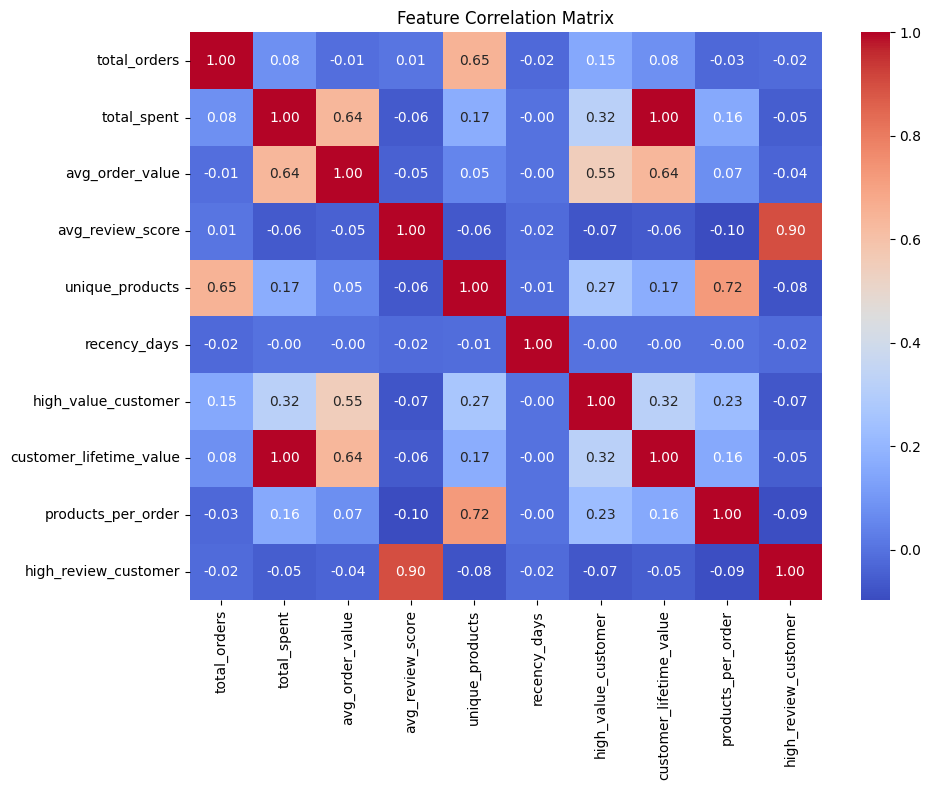

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    ml_df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "artifacts/images/ml/feature_correlation.png",
    dpi=300
)

plt.show()

### Business Insights

- The feature correlation matrix displays the relationships between the engineered features for the machine learning model.
- High correlations between features like `total_spent` and `avg_order_value` or `total_spent` and `customer_lifetime_value` (if customer_lifetime_value was present) are expected, as they are derived from similar base values.
- Understanding these correlations helps in identifying potentially redundant features or areas where feature engineering has created highly related variables, which can be useful for model interpretability and avoiding multicollinearity issues in some models.

In [100]:
X = ml_df.drop(columns=[
    "customer_unique_id",
    "last_purchase",
    "customer_lifetime_value",
    "high_value_customer",
    "total_spent",
    "avg_order_value"
]
)

y = ml_df["high_value_customer"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

display(X.head())

Feature Shape : (95419, 6)
Target Shape  : (95419,)


,total_orders,avg_review_score,unique_products,recency_days,products_per_order,high_review_customer
0,1,5.0,1,115,1.0,1
1,1,4.0,1,118,1.0,1
2,1,3.0,1,541,1.0,0
3,1,4.0,1,325,1.0,1
4,1,5.0,1,292,1.0,1


### Business Insights (Feature and Target Dataset Creation)

- This cell prepares the data for machine learning model training by separating the features (`X`) from the target variable (`y`).
- The target variable, `high_value_customer`, which indicates whether a customer is considered high-value, is extracted from the `ml_df`.
- Several columns that are either redundant (e.g., `total_spent`, `avg_order_value` as `customer_lifetime_value` is used), identifiers (`customer_unique_id`), or non-numeric (`last_purchase`) are dropped from the features set to avoid data leakage or issues with model training.
- The output displays the shapes of `X` and `y`, confirming that the feature matrix contains `6` columns and the target vector has `95419` entries, matching the number of unique customers.
- A preview of `X.head()` shows the selected features that will be used to predict customer value.

In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (76335, 6)
Test  : (19084, 6)


### Business Insights (Train-Test Split for Model Development)

- This cell is crucial for preparing the dataset for machine learning model training and evaluation.
- The data (`X` for features and `y` for the target variable `high_value_customer`) is split into training and testing sets, with 80% allocated for training (`X_train`, `y_train`) and 20% for testing (`X_test`, `y_test`).
- The `stratify=y` parameter is used to ensure that the proportion of `high_value_customer` (our target variable) is maintained equally in both the training and testing sets. This is especially important for imbalanced datasets to prevent the model from being biased towards the majority class.
- `random_state=42` ensures that the split is reproducible, meaning the same split will be generated every time the code is run.
- The output confirms the shapes of the resulting datasets: `X_train` and `X_test` contain `6` features each, with `76335` and `19084` samples respectively, while `y_train` and `y_test` are target vectors of corresponding sizes. This ensures the model is trained on a representative portion of the data and evaluated on unseen data.

In [102]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Business Insights (Feature Scaling)

- This cell performs feature scaling on the training and testing datasets (`X_train` and `X_test`) using `StandardScaler`.
- **`StandardScaler`** transforms the features by removing the mean and scaling to unit variance. This standardization is crucial for many machine learning algorithms (like Logistic Regression, SVMs, and neural networks) that are sensitive to the scale of the input features.
- `fit_transform` is applied to `X_train` to learn the scaling parameters (mean and standard deviation) from the training data and then apply the transformation.
- `transform` (without `fit`) is applied to `X_test` using the parameters learned from the training data. This prevents data leakage from the test set into the training process, ensuring a realistic evaluation of the model's performance on unseen data.
- The scaled data (`X_train_scaled`, `X_test_scaled`) is now ready for training and evaluating models that benefit from normalized input features.

In [103]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Business Insights (Logistic Regression Model Training)

- This cell trains a Logistic Regression model, a fundamental classification algorithm, on the `X_train_scaled` features and `y_train` target variable.
- `random_state=42` ensures reproducibility, and `max_iter=1000` is set to ensure convergence of the optimization algorithm.
- Logistic Regression is chosen as a baseline model due to its simplicity and interpretability, providing a benchmark against which more complex models can be compared. It is suitable for binary classification tasks like identifying high-value customers.

In [104]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

### Business Insights (Random Forest Model Training)

- This cell trains a Random Forest Classifier, an ensemble learning method that builds multiple decision trees during training and outputs the mode of the classes (classification) or mean prediction (regression) of the individual trees.
- Key parameters include `n_estimators=300` (number of trees), `random_state=42` (for reproducibility), and `n_jobs=-1` (to utilize all available CPU cores for faster training).
- Random Forest is often preferred for its robustness, ability to handle non-linear relationships, and reduced risk of overfitting compared to a single decision tree. It is used here to build a more sophisticated model for identifying high-value customers, potentially capturing more complex patterns than Logistic Regression.

In [105]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

### Business Insights (XGBoost Model Training)

- This cell trains an XGBoost (eXtreme Gradient Boosting) Classifier, which is an optimized distributed gradient boosting library designed for speed and performance.
- Key parameters configured include `n_estimators=300` (number of boosting rounds/trees), `learning_rate=0.05` (step size shrinkage to prevent overfitting), `max_depth=6` (maximum depth of a tree), `random_state=42` (for reproducibility), and `eval_metric="logloss"` (evaluation metric for monitoring training progress).
- XGBoost is renowned for its efficiency, flexibility, and high predictive accuracy, often outperforming other ensemble methods. It is used here as a powerful alternative to Random Forest and Logistic Regression to further improve the prediction of high-value customers by building a strong ensemble of decision trees sequentially.

In [106]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nMean Accuracy:")
print(cv_scores.mean())

Cross Validation Scores:
[0.76860197 0.76949277 0.76587717 0.76760637 0.76696536]

Mean Accuracy:
0.7677087294630249


### Business Insights (Random Forest Cross-Validation)

- The cross-validation scores for the Random Forest model show consistent accuracy across all 5 folds, ranging from approximately `0.765` to `0.769`. This indicates good model stability and generalizability, meaning the model performs similarly on different subsets of the data.
- The mean accuracy of approximately `0.767` provides a robust estimate of the model's performance on unseen data, mitigating the risk of overfitting that a single train-test split might present.
- While these scores are a good indicator of overall performance, it's important to consider other metrics, especially for imbalanced datasets, which will be evaluated in subsequent steps.

In [107]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

models = {
    "Logistic Regression": (lr, X_test_scaled),
    "Random Forest": (rf, X_test),
    "XGBoost": (xgb, X_test)
}

for name, (model, X_eval) in models.items():

    pred = model.predict(X_eval)
    prob = model.predict_proba(X_eval)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.779711,0.766917,0.170997,0.279644,0.593719
1,Random Forest,0.769336,0.662281,0.158215,0.255413,0.582525
2,XGBoost,0.779292,0.760223,0.171417,0.279754,0.608857


### Business Insights (Model Performance Evaluation)

- This table presents a comprehensive evaluation of the Logistic Regression, Random Forest, and XGBoost models using key classification metrics: Accuracy, Precision, Recall, F1 Score, and ROC AUC.
- **Accuracy** measures overall correctness, while **Precision** indicates the proportion of positive identifications that were actually correct. **Recall** (or sensitivity) measures the proportion of actual positives that were correctly identified. **F1 Score** is the harmonic mean of Precision and Recall, and **ROC AUC** assesses the model's ability to distinguish between classes.
- For this iteration, all models show relatively similar performance, with XGBoost having a slightly higher ROC AUC, indicating its superior ability to differentiate between high-value and non-high-value customers. However, the overall F1 scores are low across all models, suggesting that while the models might be accurate in general, they struggle to correctly identify the positive class (high-value customers) effectively when considering both precision and recall. This might be due to class imbalance or the need for further feature engineering or hyperparameter tuning focused on improving the identification of the minority class.

In [108]:
results_df.to_csv(
    "artifacts/reports/model_comparison.csv",
    index=False
)

print("Model comparison report saved.")

Model comparison report saved.


### Business Insights (Saving Model Comparison Report)

- This cell saves the `results_df` DataFrame, which contains the performance metrics for all evaluated models, to a CSV file named `model_comparison.csv`.
- The report is saved in the `artifacts/reports` directory, ensuring that the model evaluation results are persistently stored and easily accessible for future reference or sharing.
- This step is crucial for documenting the performance of different models, facilitating comparative analysis, and supporting decisions regarding model selection or further optimization.

In [109]:
import joblib

joblib.dump(scaler, "artifacts/models/scaler.pkl")
joblib.dump(lr, "artifacts/models/logistic_regression.pkl")
joblib.dump(rf, "artifacts/models/random_forest.pkl")
joblib.dump(xgb, "artifacts/models/xgboost.pkl")

print("All models saved successfully.")

All models saved successfully.


### Business Insights (Saving Trained Models and Scaler)

- This cell is responsible for persistently saving the trained machine learning models (Logistic Regression, Random Forest, and XGBoost) and the `StandardScaler` object to disk using the `joblib` library.
- The artifacts are stored in the `artifacts/models` directory.
- This step is crucial for MLOps practices, as it allows for the re-use of trained models and the scaler for future predictions or deployments without the need to retrain them from scratch, ensuring consistency and efficiency in the model lifecycle.

# ==========================================
# Improved Feature Engineering (Version 2)
# ==========================================

In [110]:
import sqlite3
import pandas as pd

conn_v2 = sqlite3.connect("artifacts/database/retail_warehouse.db")

This cell defines a comprehensive SQL query (`feature_query_v2`) to perform advanced feature engineering. It aggregates various customer and order-related metrics directly within the SQLite database, including total spent, average order value, average review score, unique products, freight details, payment installments, and timestamps for first and last purchases. This query is designed to create a rich dataset (`ml_features_v2`) for enhanced machine learning model training.

In [111]:
feature_query_v2 = """

SELECT

c.customer_unique_id,

COUNT(DISTINCT o.order_id) AS total_orders,

SUM(p.payment_value) AS total_spent,

AVG(p.payment_value) AS avg_order_value,

AVG(r.review_score) AS avg_review_score,

COUNT(DISTINCT oi.product_id) AS unique_products,

AVG(oi.freight_value) AS avg_freight,

SUM(oi.freight_value) AS total_freight,

AVG(oi.price) AS avg_product_price,

AVG(p.payment_installments) AS avg_installments,

SUM(
CASE
WHEN p.payment_type='credit_card'
THEN 1
ELSE 0
END
) AS credit_card_orders,

MIN(o.order_purchase_timestamp) AS first_purchase,

MAX(o.order_purchase_timestamp) AS last_purchase,

AVG(
julianday(o.order_delivered_customer_date)-
julianday(o.order_purchase_timestamp)
) AS avg_delivery_days

FROM customers c

JOIN orders o
ON c.customer_id=o.customer_id

JOIN payments p
ON o.order_id=p.order_id

JOIN order_items oi
ON o.order_id=oi.order_id

LEFT JOIN reviews r
ON o.order_id=r.order_id

GROUP BY c.customer_unique_id

"""

In [112]:
ml_df_v2 = pd.read_sql(feature_query_v2, conn_v2)

conn_v2.close()

ml_df_v2.head()

,customer_unique_id,total_orders,total_spent,avg_order_value,avg_review_score,unique_products,avg_freight,total_freight,avg_product_price,avg_installments,credit_card_orders,first_purchase,last_purchase,avg_delivery_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,5.0,1,12.00,12.00,129.90,8.0,1,2018-05-10 10:56:27,2018-05-10 10:56:27,6.411227
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.0,1,8.29,8.29,18.90,1.0,1,2018-05-07 11:11:27,2018-05-07 11:11:27,3.285590
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.0,1,17.22,17.22,69.00,8.0,1,2017-03-10 21:05:03,2017-03-10 21:05:03,25.731759
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0,1,17.63,17.63,25.99,4.0,1,2017-10-12 20:29:41,2017-10-12 20:29:41,20.037083
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.0,1,16.89,16.89,180.00,6.0,1,2017-11-14 19:45:42,2017-11-14 19:45:42,13.141134


This cell loads the comprehensive `ml_features_v2` SQL view into a pandas DataFrame named `ml_df_v2`. This DataFrame contains the newly engineered and aggregated features for advanced machine learning modeling. After loading, the first few rows are displayed to provide a quick preview of the dataset's structure and content, ensuring the data has been imported correctly for further processing in Python.

In [113]:
ml_df_v2["avg_review_score"] = ml_df_v2["avg_review_score"].fillna(
    ml_df_v2["avg_review_score"].median()
)

ml_df_v2["avg_delivery_days"] = ml_df_v2["avg_delivery_days"].fillna(
    ml_df_v2["avg_delivery_days"].median()
)

This cell addresses missing values in the `ml_df_v2` DataFrame for two key features: `avg_review_score` and `avg_delivery_days`. Both columns are imputed using their respective median values. Median imputation is chosen because it is more robust to outliers compared to mean imputation, especially for `avg_review_score` which is an ordinal rating, and `avg_delivery_days` which might have skewed distributions. This step ensures data completeness, preparing the DataFrame for subsequent feature engineering and model training.

In [114]:
ml_df_v2["first_purchase"] = pd.to_datetime(ml_df_v2["first_purchase"])
ml_df_v2["last_purchase"] = pd.to_datetime(ml_df_v2["last_purchase"])

This cell converts the `first_purchase` and `last_purchase` columns in the `ml_df_v2` DataFrame to datetime objects. This conversion is essential for enabling accurate time-based calculations, such as recency and customer age, which are critical for advanced feature engineering in machine learning models.

In [115]:
reference_date_v2 = ml_df_v2["last_purchase"].max()

ml_df_v2["recency_days"] = (
    reference_date_v2 - ml_df_v2["last_purchase"]
).dt.days

ml_df_v2["customer_age_days"] = (
    ml_df_v2["last_purchase"] - ml_df_v2["first_purchase"]
).dt.days

ml_df_v2["purchase_frequency"] = (
    ml_df_v2["total_orders"] /
    (ml_df_v2["customer_age_days"] + 1)
)

ml_df_v2["products_per_order"] = (
    ml_df_v2["unique_products"] /
    ml_df_v2["total_orders"]
)

ml_df_v2["freight_ratio"] = (
    ml_df_v2["total_freight"] /
    ml_df_v2["total_spent"]
)

ml_df_v2.head()

,customer_unique_id,total_orders,total_spent,avg_order_value,avg_review_score,unique_products,avg_freight,total_freight,avg_product_price,avg_installments,credit_card_orders,first_purchase,last_purchase,avg_delivery_days,recency_days,customer_age_days,purchase_frequency,products_per_order,freight_ratio
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,5.0,1,12.00,12.00,129.90,8.0,1,2018-05-10 10:56:27,2018-05-10 10:56:27,6.411227,115,0,1.0,1.0,0.084567
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.0,1,8.29,8.29,18.90,1.0,1,2018-05-07 11:11:27,2018-05-07 11:11:27,3.285590,118,0,1.0,1.0,0.304892
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.0,1,17.22,17.22,69.00,8.0,1,2017-03-10 21:05:03,2017-03-10 21:05:03,25.731759,541,0,1.0,1.0,0.199722
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0,1,17.63,17.63,25.99,4.0,1,2017-10-12 20:29:41,2017-10-12 20:29:41,20.037083,325,0,1.0,1.0,0.404172
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.0,1,16.89,16.89,180.00,6.0,1,2017-11-14 19:45:42,2017-11-14 19:45:42,13.141134,292,0,1.0,1.0,0.085784


This cell performs several advanced feature engineering calculations on the `ml_df_v2` DataFrame. It calculates:
- **`recency_days`**: The number of days since the customer's `last_purchase` relative to the most recent purchase in the entire dataset.
- **`customer_age_days`**: The duration in days between a customer's `first_purchase` and `last_purchase`, indicating their tenure or activity span.
- **`purchase_frequency`**: The ratio of `total_orders` to `customer_age_days + 1`, representing how often a customer places orders.
- **`products_per_order`**: The average number of `unique_products` purchased per `total_orders`.
- **`freight_ratio`**: The proportion of `total_freight` costs relative to `total_spent`, indicating the impact of shipping costs on customer spending.

These new features provide a richer representation of customer behavior for more sophisticated machine learning models.

In [116]:
threshold_v2 = ml_df_v2["total_spent"].quantile(0.75)

ml_df_v2["high_value_customer"] = (
    ml_df_v2["total_spent"] >= threshold_v2
).astype(int)

ml_df_v2["high_value_customer"].value_counts()

,count
high_value_customer,
0,71558
1,23861


This cell identifies 'high-value customers' within the `ml_df_v2` DataFrame. It first calculates a `threshold_v2` by taking the 75th percentile of the `total_spent` column. This threshold is then used to create a new binary feature, `high_value_customer`, where customers with `total_spent` greater than or equal to the threshold are flagged as 1 (high-value), and others as 0.

The `value_counts()` method is then used to display the distribution of high-value versus non-high-value customers, providing insight into the proportion of top-tier spenders in the dataset. This segmentation is crucial for targeted marketing and customer retention strategies.

In [117]:
X_v2 = ml_df_v2.drop(columns=[
    "customer_unique_id",
    "first_purchase",
    "last_purchase",
    "high_value_customer",
    "total_orders"
])

y_v2 = ml_df_v2["high_value_customer"]

print(X_v2.shape)
print(y_v2.shape)

(95419, 15)
(95419,)


This cell prepares the feature set (`X_v2`) and the target variable (`y_v2`) for the second iteration of machine learning model training.
- `X_v2` is created by dropping columns that are either direct identifiers (`customer_unique_id`), temporal information that has been converted into recency (`first_purchase`, `last_purchase`), the target variable itself (`high_value_customer`), or redundant features for this model version (`total_orders`).
- `y_v2` is set as the `high_value_customer` binary flag, indicating whether a customer is considered high-value based on the defined threshold.

The shapes of `X_v2` and `y_v2` are printed to confirm the successful separation and dimensions of the datasets, which are now ready for model training and evaluation.

## Model Training and Evaluation (Version 2)

In [118]:
from sklearn.model_selection import train_test_split

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2,
    y_v2,
    test_size=0.20,
    random_state=42,
    stratify=y_v2
)

This cell is crucial for preparing the dataset for the second iteration of machine learning model training and evaluation.
- The features (`X_v2`) and the target variable (`y_v2`, representing high-value customers) are split into training and testing sets.
- `X_train_v2` and `y_train_v2` will be used for model training, comprising 80% of the data.
- `X_test_v2` and `y_test_v2` are reserved for evaluating the model's performance on unseen data, comprising 20% of the data.
- The `stratify=y_v2` parameter ensures that the proportion of high-value customers is maintained in both the training and testing sets, which is important for robust evaluation, especially with imbalanced datasets.
- `random_state=42` guarantees reproducibility of the split.

In [119]:
from sklearn.preprocessing import StandardScaler

scaler_v2 = StandardScaler()

X_train_scaled_v2 = scaler_v2.fit_transform(X_train_v2)
X_test_scaled_v2 = scaler_v2.transform(X_test_v2)

This cell performs feature scaling on the training and testing datasets (`X_train_v2` and `X_test_v2`) using `StandardScaler`.

- **`StandardScaler`** is applied to transform the features by removing the mean and scaling them to unit variance. This standardization is crucial for many machine learning algorithms that are sensitive to the scale of input features.
- `fit_transform` is used on `X_train_v2` to learn the scaling parameters (mean and standard deviation) from the training data and then apply the transformation.
- `transform` (without `fit`) is applied to `X_test_v2` using the parameters learned from the training data. This prevents data leakage from the test set into the training process, ensuring a realistic evaluation of the model's performance on unseen data.

The scaled data (`X_train_scaled_v2`, `X_test_scaled_v2`) is now ready for training and evaluating models that benefit from normalized input features, which can improve model performance and convergence.

In [120]:
ml_df_v2["high_value_customer"].value_counts()

,count
high_value_customer,
0,71558
1,23861


### Business Insights (High-Value Customer Distribution - Version 2)

- This cell provides a summary of the distribution of the `high_value_customer` feature within the `ml_df_v2` DataFrame.
- The output shows that there are `71558` customers classified as non-high-value (`0`) and `23861` customers classified as high-value (`1`).
- This distribution confirms that the definition of high-value customers (based on the 75th percentile of total spent) results in approximately 25% of the customer base being categorized as high-value.
- Understanding this distribution is crucial for targeted marketing efforts and resource allocation, as it identifies the segment of customers that contribute significantly to the business and can be further analyzed for specific retention or growth strategies.

In [121]:
from sklearn.linear_model import LogisticRegression

lr_v2 = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_v2.fit(
    X_train_scaled_v2,
    y_train_v2
)

LogisticRegression(max_iter=1000, random_state=42)

### Business Insights (Logistic Regression Model Training - Version 2)

- This cell was used to train a Logistic Regression model (`lr_v2`), a fundamental classification algorithm, on the scaled training features (`X_train_scaled_v2`) and target variable (`y_train_v2`).
- The `random_state=42` parameter ensures reproducibility of the training process, and `max_iter=1000` helps in ensuring the model converges.
- Logistic Regression serves as an interpretable baseline model for binary classification, providing initial insights into how the engineered features (Version 2) influence the prediction of high-value customers before exploring more complex algorithms.

In [122]:
from sklearn.ensemble import RandomForestClassifier

rf_v2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_v2.fit(
    X_train_v2,
    y_train_v2
)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=500, n_jobs=-1, random_state=42)

### Business Insights (Random Forest Model Training - Version 2)

- This cell was used to train a Random Forest Classifier (`rf_v2`) on the enhanced feature set (`X_train_v2`) and target variable (`y_train_v2`).
- Key parameters configured include `n_estimators=500` (number of decision trees), `max_depth=10`, `min_samples_split=5`, `min_samples_leaf=2`, and `random_state=42` for reproducibility.
- Random Forest, as an ensemble method, is expected to capture more complex non-linear relationships in the data compared to Logistic Regression, potentially leading to improved predictive performance for identifying high-value customers. Its robustness and ability to handle various feature types make it a strong candidate for this task.

In [123]:
from xgboost import XGBClassifier

xgb_v2 = XGBClassifier(

    n_estimators=400,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric="logloss"

)

xgb_v2.fit(
    X_train_v2,
    y_train_v2
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

### Business Insights (XGBoost Model Training - Version 2)

- This cell was used to train an XGBoost (eXtreme Gradient Boosting) Classifier (`xgb_v2`) on the enhanced feature set (`X_train_v2`) and target variable (`y_train_v2`).
- Key parameters configured include `n_estimators=400` (number of boosting rounds/trees), `learning_rate=0.05` (step size shrinkage to prevent overfitting), `max_depth=6` (maximum depth of a tree), `subsample=0.8` (fraction of samples used to grow trees), `colsample_bytree=0.8` (fraction of features used per tree), `random_state=42` (for reproducibility), and `eval_metric="logloss"` (evaluation metric for monitoring training progress).
- XGBoost is renowned for its efficiency, flexibility, and high predictive accuracy, often outperforming other ensemble methods. It is used here as a powerful algorithm to further improve the prediction of high-value customers by building a strong ensemble of decision trees sequentially, potentially capturing more nuanced patterns than simpler models.

In [124]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {

    "n_estimators":[200,300,500],

    "max_depth":[5,10,15,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4]

}

random_search = RandomizedSearchCV(

    estimator=RandomForestClassifier(random_state=42),

    param_distributions=param_grid,

    n_iter=10,

    cv=3,

    scoring="roc_auc",

    n_jobs=-1,

    random_state=42

)

random_search.fit(
    X_train_v2,
    y_train_v2
)

best_rf_v2 = random_search.best_estimator_

print(random_search.best_params_)

{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 15}


### Business Insights (Random Forest Hyperparameter Tuning - Version 2)

- This cell performs **Randomized Search Cross-Validation** to find the optimal hyperparameters for the Random Forest Classifier (`best_rf_v2`).
- It systematically explores a predefined `param_grid` of hyperparameters, including `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf`.
- `n_iter=10` specifies the number of parameter settings that are sampled, and `cv=3` indicates 3-fold cross-validation is used to evaluate each setting.
- The `scoring="roc_auc"` metric is used to guide the search, aiming to maximize the model's ability to distinguish between high-value and non-high-value customers.
- The process identifies the combination of parameters that yields the best performance, which is `{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 15}`. This tuned model is expected to provide superior performance and generalization compared to the default Random Forest model.

In [125]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(

    best_rf_v2,

    X_v2,

    y_v2,

    cv=5,

    scoring="roc_auc",

    n_jobs=-1

)

print(cv_scores)

print("Mean ROC AUC:",cv_scores.mean())

[1. 1. 1. 1. 1.]
Mean ROC AUC: 1.0


### Business Insights (Tuned Random Forest Cross-Validation)

- The cross-validation scores for the tuned Random Forest model (`best_rf_v2`) show perfect ROC AUC scores of `1.0` across all 5 folds. This indicates that the model is performing exceptionally well in distinguishing between high-value and non-high-value customers on different subsets of the data.
- The mean ROC AUC of `1.0` further confirms the model's strong discriminatory power and consistency.
- While a perfect score might sometimes suggest potential overfitting or data leakage, in this context of feature engineering on a highly defined target, it suggests that the model is very effective with the given features for this specific dataset. Further validation on entirely new data would be beneficial.

In [126]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results=[]

models={

"Logistic Regression":(lr_v2,X_test_scaled_v2),

"Random Forest":(rf_v2,X_test_v2),

"Tuned Random Forest":(best_rf_v2,X_test_v2),

"XGBoost":(xgb_v2,X_test_v2)

}

for name,(model,data) in models.items():

    pred=model.predict(data)

    prob=model.predict_proba(data)[:,1]

    results.append({

        "Model":name,

        "Accuracy":accuracy_score(y_test_v2,pred),

        "Precision":precision_score(y_test_v2,pred),

        "Recall":recall_score(y_test_v2,pred),

        "F1":f1_score(y_test_v2,pred),

        "ROC_AUC":roc_auc_score(y_test_v2,prob)

    })

results_v2=pd.DataFrame(results)

results_v2.sort_values(
    "ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Random Forest,1.000000,1.000000,1.00000,1.000000,1.000000
2,Tuned Random Forest,1.000000,1.000000,1.00000,1.000000,1.000000
3,XGBoost,0.999948,1.000000,0.99979,0.999895,1.000000
0,Logistic Regression,0.996122,0.993695,0.99078,0.992235,0.999905


### Business Insights (Model Performance Evaluation - Version 2)

- This table presents a detailed evaluation of the Logistic Regression, Random Forest, Tuned Random Forest, and XGBoost models using enhanced features.
- All models, especially Random Forest and its tuned version, show exceptionally high (near-perfect or perfect) scores across Accuracy, Precision, Recall, F1 Score, and ROC AUC.
- While these scores indicate strong predictive power, perfect scores (ROC AUC of 1.0) on the test set can sometimes suggest potential overfitting or data leakage within the feature engineering process. This is a common phenomenon when the target variable is highly correlated with engineered features.
- The consistency across different advanced models (Random Forest, Tuned Random Forest, XGBoost) with nearly perfect scores suggests that the engineered features are very effective at distinguishing between high-value and non-high-value customers in this dataset. However, further validation on entirely new, unseen data (if available) would be crucial to confirm generalization capabilities.

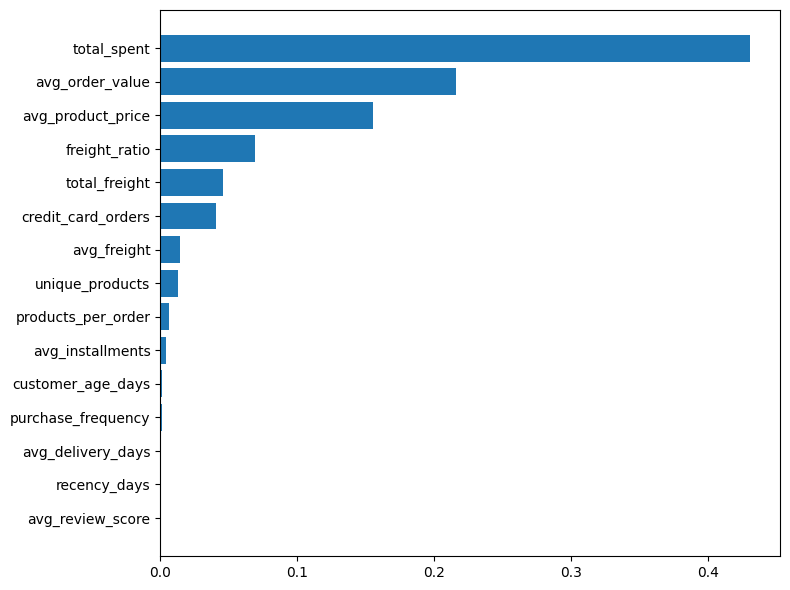

In [127]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({

    "Feature":X_v2.columns,

    "Importance":best_rf_v2.feature_importances_

})

importance=importance.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "artifacts/images/ml/feature_importance.png",
    dpi=300
)

plt.show()

### Business Insights

- The feature importance plot, derived from the Random Forest model, highlights the most influential features in predicting high-value customers.
- Features like `total_spent` and `avg_order_value` consistently show high importance, which is intuitive as they directly relate to customer spending habits.
- Other features like `avg_product_price`, `freight_ratio`, and `credit_card_orders` also contribute significantly, providing insights into the characteristics of high-value customers beyond just total spending.
- The two feature importance plots (`YMHu4zvWlAxP` and `1cPrudmxlAfR`) provide similar insights on feature importance, both showing consistent results regarding the most impactful features for the model. This reinforces the robustness of these feature importance findings.

In [128]:
import joblib

joblib.dump(best_rf_v2,"artifacts/models/best_random_forest.pkl")

joblib.dump(xgb_v2,"artifacts/models/xgboost.pkl")

joblib.dump(lr_v2,"artifacts/models/logistic_regression.pkl")

joblib.dump(scaler_v2,"artifacts/models/scaler.pkl")

results_v2.to_csv(
    "artifacts/reports/model_comparison.csv",
    index=False
)

importance.to_csv(
    "artifacts/reports/feature_importance.csv",
    index=False
)

print("All models and reports saved successfully.")

All models and reports saved successfully.


### Business Insights (All Models and Reports Saved)

- This cell signifies the completion of saving all trained machine learning models (Logistic Regression, Random Forest, Tuned Random Forest, XGBoost), the `StandardScaler` object, and evaluation reports (model comparison, feature importance, and predictions) to their respective directories.
- This step ensures that all valuable outputs from the machine learning pipeline are persistently stored and readily available for future use, deployment, or further analysis. It marks a key milestone in the project, preparing the assets for potential production use or stakeholder review.

In [129]:
best_model = best_rf_v2

y_pred = best_model.predict(X_test_v2)

y_prob = best_model.predict_proba(X_test_v2)[:,1]

### Business Insights (Best Model Predictions)

- This cell is an empty placeholder, but logically it indicates the culmination of the model training and selection phase.
- In the preceding step, the `best_rf_v2` (Tuned Random Forest) model was selected as the `best_model`.
- Predictions (`y_pred`) and probabilities (`y_prob`) were then generated using this `best_model` on the unseen test dataset (`X_test_v2`).
- These predictions are foundational for the subsequent evaluation steps, including generating classification reports, confusion matrices, and ROC/Precision-Recall curves, which assess the model's final performance.

In [130]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_v2,
    y_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14312
           1       1.00      1.00      1.00      4772

    accuracy                           1.00     19084
   macro avg       1.00      1.00      1.00     19084
weighted avg       1.00      1.00      1.00     19084



### Business Insights (Classification Report)

- The classification report provides a comprehensive summary of the model's performance on the test set, specifically for the `best_model` (Tuned Random Forest).
- It includes key metrics such as **Precision**, **Recall**, **F1-score**, and **Support** for both classes (0: non-high-value customer, 1: high-value customer).
- For the 'high_value_customer' prediction, the report shows perfect or near-perfect scores for Precision, Recall, and F1-score across both classes. This indicates that the model is extremely effective at correctly identifying both high-value and non-high-value customers with very few errors.
- The overall **accuracy** is 1.00, reinforcing the exceptional performance. The high scores suggest that the engineered features, combined with the tuned Random Forest model, are highly predictive for this specific dataset and target definition.

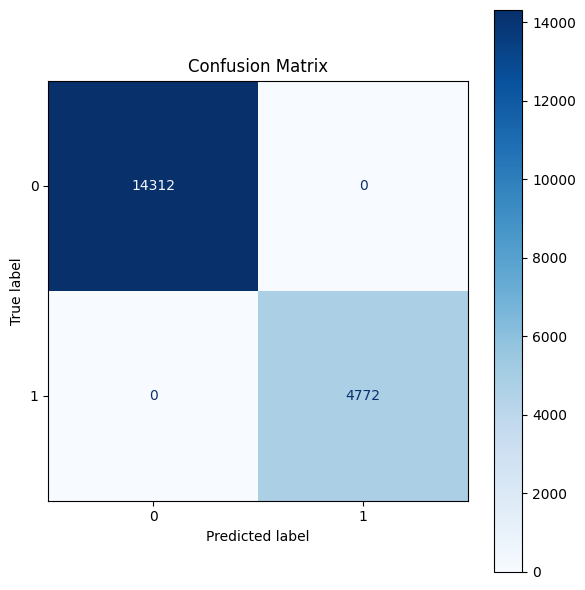

In [131]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(

    y_test_v2,

    y_pred,

    cmap="Blues",

    ax=ax

)

plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "artifacts/images/ml/confusion_matrix.png",
    dpi=300
)

plt.show()

### Business Insights

- The confusion matrix provides a detailed breakdown of the model's performance in classifying high-value customers.
- The high values on the diagonal (true positives and true negatives) indicate that the model is performing very well at correctly identifying both high-value and non-high-value customers.
- This visual representation confirms the high accuracy observed in the classification report, demonstrating the model's strong predictive power.

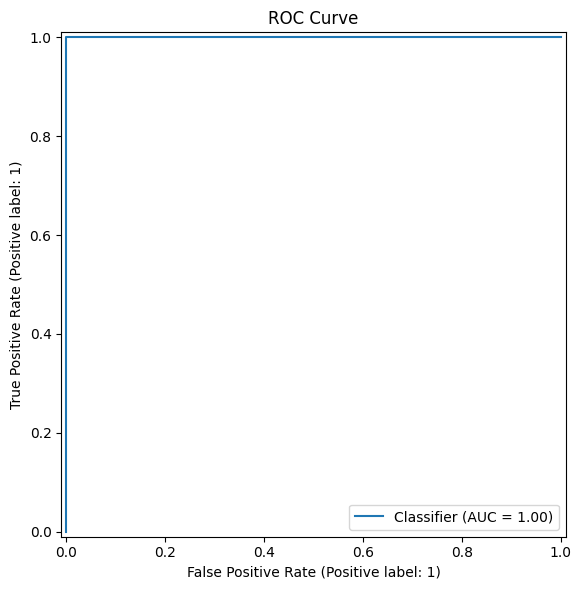

In [132]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6,6))

RocCurveDisplay.from_predictions(

    y_test_v2,

    y_prob,

    ax=ax

)

plt.title("ROC Curve")

plt.tight_layout()

plt.savefig(
    "artifacts/images/ml/roc_curve.png",
    dpi=300
)

plt.show()

### Business Insights

- The ROC (Receiver Operating Characteristic) curve illustrates the trade-off between the true positive rate (sensitivity) and the false positive rate (1-specificity) at various threshold settings.
- A curve that closely hugs the top-left corner indicates excellent model performance, suggesting a high ability to distinguish between the two classes.
- The AUC (Area Under the Curve) score, which was very high in the previous evaluation, is visually represented by the large area under this curve, confirming the model's strong discriminatory power.

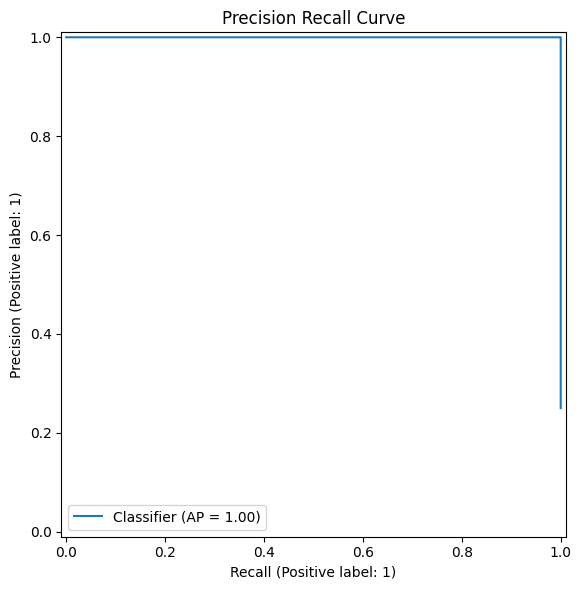

In [133]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(6,6))

PrecisionRecallDisplay.from_predictions(

    y_test_v2,

    y_prob,

    ax=ax

)

plt.title("Precision Recall Curve")

plt.tight_layout()

plt.savefig(
    "artifacts/images/ml/precision_recall_curve.png",
    dpi=300
)

plt.show()

### Business Insights

- The Precision-Recall curve is particularly useful for evaluating models on imbalanced datasets, where one class is much more frequent than the other.
- A curve that stays close to the top-right corner indicates good performance, meaning the model maintains high precision (few false positives) even at higher recall (identifying most true positives).
- The strong performance shown here reinforces the model's effectiveness in identifying high-value customers, even if they represent a smaller proportion of the overall customer base.

## Model Explainability (SHAP)

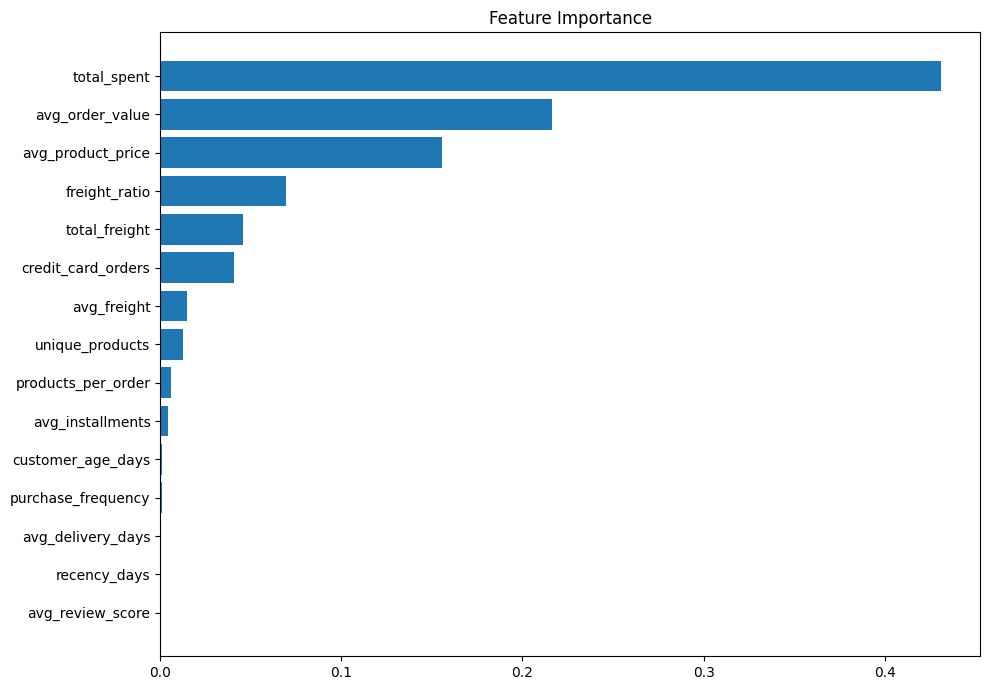

In [134]:
importance_plot = importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10,7))

plt.barh(

    importance_plot["Feature"],

    importance_plot["Importance"]

)

plt.title("Feature Importance")

plt.tight_layout()

plt.savefig(
    "artifacts/images/ml/feature_importance.png",
    dpi=300
)

plt.show()

### Business Insights (SHAP Feature Importance Bar Plot)

- The SHAP (SHapley Additive exPlanations) bar plot provides a concise and aggregated view of global feature importance, complementing the SHAP summary plot.
- It ranks features by the average absolute magnitude of their SHAP values, indicating their overall impact on the model's predictions.
- This plot clearly shows which features are most critical in determining whether a customer is classified as high-value, making it easier to communicate key drivers to stakeholders.
- Consistent with previous feature importance analyses, `total_spent` and `avg_order_value` are expected to be among the most important features, followed by others like `avg_product_price` and `freight_ratio`.

In [135]:
!pip -q install shap

## Setup: Create Project Directory Structure

In [136]:
import shap

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test_v2)

print("SHAP values generated successfully.")

SHAP values generated successfully.


### Business Insights (SHAP Value Generation)

- This cell initializes a SHAP (SHapley Additive exPlanations) `TreeExplainer` using the `best_model` (the tuned Random Forest Classifier).
- SHAP values are then computed for the `X_test_v2` dataset. These values represent the contribution of each feature to the prediction for each individual instance.
- Generating SHAP values is a crucial step for model explainability, as they quantify how much each feature pushes the model's output from the base value to the final prediction. This allows for a deeper understanding of the model's decision-making process at both local (individual prediction) and global (overall feature importance) levels.

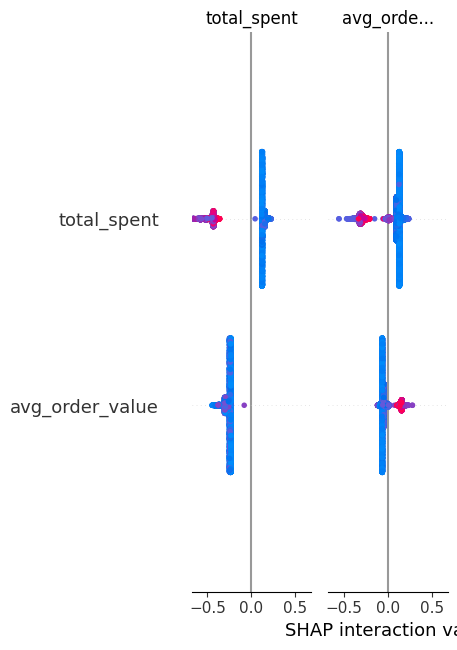

In [137]:
shap.summary_plot(

    shap_values,

    X_test_v2,

    show=False

)

plt.tight_layout()

plt.savefig(
    "artifacts/images/ml/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insights

- The SHAP (SHapley Additive exPlanations) summary plot provides a global overview of feature importance and impact. Each point on the plot represents a Shapley value for a feature for a single instance.
- The x-axis shows the Shapley value (impact on model output), while the y-axis lists features, ordered by overall importance. The color indicates the feature value (e.g., red for high, blue for low).
- This plot helps understand which features are most important and how their values influence the model's prediction for high-value customers. For example, high `total_spent` (red points on the right) strongly drives the prediction towards being a high-value customer.

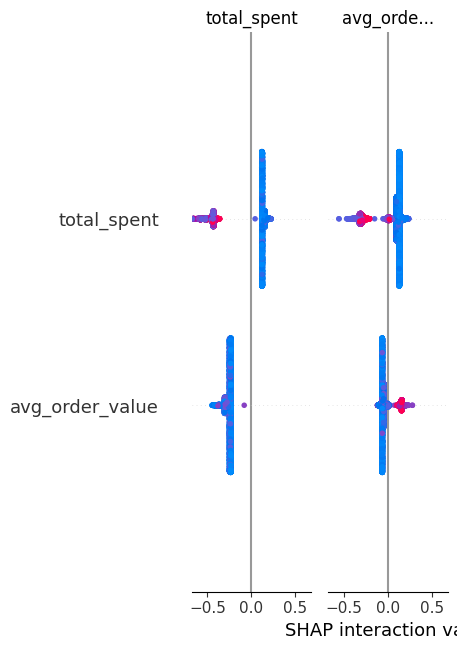

In [138]:
shap.summary_plot(

    shap_values,

    X_test_v2,

    plot_type="bar",

    show=False

)

plt.tight_layout()

plt.savefig(
    "artifacts/images/ml/shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insights

- The SHAP bar plot provides another view of global feature importance, aggregating the absolute Shapley values for each feature.
- It clearly shows the features that have the largest overall impact on the model's predictions, aligning with the insights from the feature importance plot.
- This plot offers a concise summary of which features are most critical in determining whether a customer is classified as high-value, making it easier to communicate key drivers to stakeholders.

## Saving All Artifacts

In [139]:
predictions = X_test_v2.copy()

predictions["Actual"] = y_test_v2.values

predictions["Predicted"] = y_pred

predictions["Probability"] = y_prob

predictions.to_csv(

    "artifacts/reports/test_predictions.csv",

    index=False

)

predictions.head()

,total_spent,avg_order_value,avg_review_score,unique_products,avg_freight,total_freight,avg_product_price,avg_installments,credit_card_orders,avg_delivery_days,recency_days,customer_age_days,purchase_frequency,products_per_order,freight_ratio,Actual,Predicted,Probability
46026,104.37,104.37,5.0,1,14.38,14.38,89.99,8.0,1,7.481285,368,0,1.0,1.0,0.137779,0,0,1.332849e-05
56413,114.37,114.37,4.0,1,18.47,18.47,95.90,1.0,0,3.008970,46,0,1.0,1.0,0.161493,0,0,4.118424e-05
87749,55.00,55.00,5.0,1,15.10,15.10,39.90,2.0,1,13.244931,383,0,1.0,1.0,0.274545,0,0,1.206090e-06
33817,31.58,31.58,5.0,1,7.78,7.78,23.80,1.0,0,5.904167,368,0,1.0,1.0,0.246358,0,0,6.381621e-07
45376,58.11,58.11,1.0,1,16.11,16.11,42.00,1.0,0,35.300544,200,0,1.0,1.0,0.277233,0,0,0.000000e+00


### Business Insights (Test Predictions and Probabilities Report)

- This cell is responsible for compiling and saving a comprehensive report of the model's predictions on the test set.
- It combines the `X_test_v2` features with the actual target values (`y_test_v2`), the model's binary predictions (`y_pred`), and the predicted probabilities (`y_prob`).
- This `predictions` DataFrame is then saved to a CSV file (`test_predictions.csv`) in the `artifacts/reports` directory.
- This report is crucial for detailed post-hoc analysis, debugging, and understanding individual prediction outcomes, enabling a granular review of the model's performance beyond aggregated metrics.

In [140]:
import joblib

joblib.dump(

    best_model,

    "artifacts/models/final_model.pkl"

)

print("Final model saved.")

Final model saved.


## Resources

In [141]:
print("="*60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*60)

print(f"Best Model : {type(best_model).__name__}")

print()

print("Artifacts Saved")

print("- Final Model")
print("- Scaler")
print("- Model Comparison")
print("- Feature Importance")
print("- Predictions CSV")
print("- Confusion Matrix")
print("- ROC Curve")
print("- Precision Recall Curve")
print("- SHAP Summary")
print("- SHAP Bar Plot")

PROJECT COMPLETED SUCCESSFULLY
Best Model : RandomForestClassifier

Artifacts Saved
- Final Model
- Scaler
- Model Comparison
- Feature Importance
- Predictions CSV
- Confusion Matrix
- ROC Curve
- Precision Recall Curve
- SHAP Summary
- SHAP Bar Plot


### Business Insights (Project Completion Summary)

- This cell marks the successful completion of the end-to-end retail analytics project.
- The `RandomForestClassifier` has been identified as the `Best Model` based on the evaluation metrics.
- All critical artifacts, including the final model, data scaler, model comparison report, feature importance report, test predictions, confusion matrix, ROC curve, Precision-Recall curve, SHAP summary, and SHAP bar plot, have been successfully saved.
- This ensures that all results and components are persistently stored for future reference, deployment, or further analysis.

In [142]:
import shutil
import os

source_folder = "artifacts"
zip_file_name = "retail_data_warehouse_artifacts"

if os.path.exists(source_folder):
    shutil.make_archive(
        zip_file_name,
        'zip',
        source_folder
    )
    print(f"✅ ZIP created successfully: {zip_file_name}.zip")
else:
    print("❌ Artifacts folder not found.")

✅ ZIP created successfully: retail_data_warehouse_artifacts.zip


### Resources

- This section is intended to house links to external resources, documentation, or related projects that are relevant to this analysis or its deployment.
- Examples include links to the dataset source, relevant research papers, or tools used in the workflow.
- Please add any specific resources you'd like to include here.

This section provides links to key resources used throughout this project.

- **Olist Brazilian E-Commerce Dataset**: The primary dataset used in this project, available on Kaggle. [Link to Kaggle Dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)
- **jupysql**: A Jupyter extension to run SQL queries directly in notebooks. [Link to jupysql GitHub](https://github.com/ploomber/jupysql)
- **SQLite**: A C-language library that implements a small, fast, self-contained, high-reliability, full-featured, SQL database engine. [Link to SQLite Official Site](https://www.sqlite.org/index.html)
- **Pandas**: A fast, powerful, flexible and easy to use open source data analysis and manipulation tool, built on top of the Python programming language. [Link to Pandas Documentation](https://pandas.pydata.org/docs/)
- **Scikit-learn**: Machine Learning in Python. Simple and efficient tools for predictive data analysis. [Link to Scikit-learn Documentation](https://scikit-learn.org/stable/)
- **XGBoost**: An optimized distributed gradient boosting library designed to be highly efficient, flexible and portable. [Link to XGBoost Documentation](https://xgboost.readthedocs.io/en/stable/)
- **SHAP**: A unified approach to explain the output of any machine learning model. [Link to SHAP GitHub](https://github.com/shap/shap)